In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, HeteroData
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, HGTConv
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import precision_recall_curve
from collections import defaultdict
import json
from datetime import datetime
import matplotlib.image as mpimg
from IPython.display import display, Image, HTML
import os

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}\n")

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

c:\Users\patri\Desktop\code\NetworkAnalysis\.venv\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\patri\Desktop\code\NetworkAnalysis\.venv\Lib\site-packages\torch_scatter\_version_cuda.pyd
  import torch_geometric.typing
c:\Users\patri\Desktop\code\NetworkAnalysis\.venv\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\patri\Desktop\code\NetworkAnalysis\.venv\Lib\site-packages\torch_sparse\_version_cuda.pyd
  import torch_geometric.typing
c:\Users\patri\Desktop\code\NetworkAnalysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.9.1+cpu
Device: CPU



# 1. Prepare data for use with PyG

In [2]:
class BipartiteGraphDataset:
    """Load and preprocess bipartite person-condition graph"""
    
    def __init__(self, edge_file, person_file, condition_file):
        # Load data
        self.edges = pd.read_csv(edge_file)
        self.persons = pd.read_csv(person_file)
        self.conditions = pd.read_csv(condition_file)
        
        print(f"\nLoaded {len(self.edges)} edges")
        print(f"Loaded {len(self.persons)} persons")
        print(f"Loaded {len(self.conditions)} conditions")
        
        # Create ID mappings
        self._create_mappings()
        
        # Prepare features
        self._prepare_features()
        self.num_persons = len(self.person_ids)
        self.num_conditions = len(self.condition_ids)
        
    def _create_mappings(self):
        """Create bidirectional mappings between original IDs and node indices"""
        # Person mappings
        self.person_ids = sorted(self.persons['person_id'].unique())
        self.person_id_to_idx = {pid: idx for idx, pid in enumerate(self.person_ids)}
        self.person_idx_to_id = {idx: pid for pid, idx in self.person_id_to_idx.items()}
        
        # Condition mappings
        self.condition_ids = sorted(self.conditions['condition_concept_id'].unique())
        self.condition_id_to_idx = {cid: idx for idx, cid in enumerate(self.condition_ids)}
        self.condition_idx_to_id = {idx: cid for cid, idx in self.condition_id_to_idx.items()}
        
        print(f"\nMapped {len(self.person_ids)} unique persons")
        print(f"Mapped {len(self.condition_ids)} unique conditions")
        
    def _prepare_features(self):
        """Prepare node features for persons and conditions"""
        # Person features: demographics
        person_feature_cols = [
            'year_of_birth', 'gender_FEMALE', 'gender_MALE',
            'race_American Indian or Alaska Native', 'race_Asian',
            'race_Black or African American', 
            'race_Native Hawaiian or Other Pacific Islander',
            'race_No matching concept', 'race_White',
            'ethnicity_Hispanic or Latino', 'ethnicity_No matching concept',
            'ethnicity_Not Hispanic or Latino'
        ]
        
        # Sort persons by person_id to match our mapping
        persons_sorted = self.persons.sort_values('person_id').reset_index(drop=True)
        
        # Normalize year_of_birth
        yob = persons_sorted['year_of_birth'].values.reshape(-1, 1)
        yob_normalized = (yob - yob.mean()) / (yob.std() + 1e-8)
        
        # Get demographic features
        demographic_features = persons_sorted[person_feature_cols[1:]].values
        
        # Combine features
        self.person_features = np.hstack([yob_normalized, demographic_features]).astype(np.float32)
        
        print(f"\nPerson features: {self.person_features.shape}")
        print(f"\tYear of birth (normalized) + {len(person_feature_cols)-1} demographic features")
        
        # Condition features: occurrence statistics
        # Sort conditions by condition_concept_id to match our mapping
        conditions_sorted = self.conditions.sort_values('condition_concept_id').reset_index(drop=True)
        
        # Log-transform occurrences
        occurrences = conditions_sorted['occurrences'].values.reshape(-1, 1)
        log_occurrences = np.log1p(occurrences)
        log_occurrences_normalized = (log_occurrences - log_occurrences.mean()) / (log_occurrences.std() + 1e-8)
        
        # Frequency (already normalized)
        frequency = conditions_sorted['frequency'].values.reshape(-1, 1)
        
        self.condition_features = np.hstack([log_occurrences_normalized, frequency]).astype(np.float32)
        
        print(f"Condition features: {self.condition_features.shape}")
        print(f"\tLog occurrences (normalized) + frequency")
        
    def create_pyg_data(self, test_ratio=0.15, val_ratio=0.15):
        """Create PyTorch Geometric Data object with train/val/test splits"""
        # Convert edges to indices
        person_indices = [self.person_id_to_idx[pid] for pid in self.edges['person_id']]
        condition_indices = [self.condition_id_to_idx[cid] for cid in self.edges['condition_concept_id']]
        
        # Create bipartite edge index (persons -> conditions)
        edge_index = torch.tensor([person_indices, condition_indices], dtype=torch.long)
        
        print(f"\nCreated edge index: {edge_index.shape}")
        print(f"\t{edge_index.shape[1]} edges from persons to conditions")
        
        # Convert features to tensors
        person_x = torch.from_numpy(self.person_features)
        condition_x = torch.from_numpy(self.condition_features)
        
        # For homogeneous graph representation, concatenate all nodes
        # Persons: indices 0 to num_persons-1
        # Conditions: indices num_persons to num_persons+num_conditions-1
        num_persons = len(self.person_ids)
        num_conditions = len(self.condition_ids)
        
        # Pad features to same dimension
        max_dim = max(person_x.shape[1], condition_x.shape[1])
        if person_x.shape[1] < max_dim:
            person_x = F.pad(person_x, (0, max_dim - person_x.shape[1]))
        if condition_x.shape[1] < max_dim:
            condition_x = F.pad(condition_x, (0, max_dim - condition_x.shape[1]))
        
        # Combine features
        x = torch.cat([person_x, condition_x], dim=0)
        
        # Adjust edge indices for combined node set
        adjusted_edge_index = edge_index.clone()
        adjusted_edge_index[1] += num_persons  # Shift condition indices
        
        # Create bidirectional edges (undirected graph)
        edge_index_full = torch.cat([
            adjusted_edge_index,
            adjusted_edge_index.flip(0)  # Add reverse edges
        ], dim=1)
        
        # Create node type mask
        node_type = torch.zeros(num_persons + num_conditions, dtype=torch.long)
        node_type[num_persons:] = 1  # 0 for person, 1 for condition
        
        # Create PyG Data object
        data = Data(
            x=x,
            edge_index=edge_index_full,
            num_nodes=num_persons + num_conditions,
            node_type=node_type
        )
        
        # Store metadata
        data.num_persons = num_persons
        data.num_conditions = num_conditions
        data.person_node_range = (0, num_persons)
        data.condition_node_range = (num_persons, num_persons + num_conditions)
        
        print(f"\nCreated homogeneous graph:")
        print(f"  - Total nodes: {data.num_nodes}")
        print(f"  - Person nodes: {num_persons} (indices 0-{num_persons-1})")
        print(f"  - Condition nodes: {num_conditions} (indices {num_persons}-{num_persons+num_conditions-1})")
        print(f"  - Total edges (bidirectional): {data.edge_index.shape[1]}")
        print(f"  - Node features: {data.x.shape}")
        
        # Split edges for link prediction
        data = self._split_edges(data, test_ratio, val_ratio)
        
        return data
    
    def _split_edges(self, data, test_ratio, val_ratio):
        """Split edges into train/val/test for link prediction"""
        
        # Get only person->condition edges (not the reverse)
        num_persons = data.num_persons
        mask = data.edge_index[0] < num_persons
        person_to_condition_edges = data.edge_index[:, mask]
        
        num_edges = person_to_condition_edges.shape[1]
        indices = np.arange(num_edges)
        np.random.shuffle(indices)
        
        test_size = int(num_edges * test_ratio)
        val_size = int(num_edges * val_ratio)
        train_size = num_edges - test_size - val_size
        
        train_idx = indices[:train_size]
        val_idx = indices[train_size:train_size + val_size]
        test_idx = indices[train_size + val_size:]
        
        # Create edge masks
        data.train_edge_index = person_to_condition_edges[:, train_idx]
        data.val_edge_index = person_to_condition_edges[:, val_idx]
        data.test_edge_index = person_to_condition_edges[:, test_idx]
        
        # Create bidirectional train edges for message passing
        data.train_edge_index_full = torch.cat([
            data.train_edge_index,
            data.train_edge_index.flip(0)
        ], dim=1)
        
        print(f"\nEdge split:")
        print(f"  - Train edges: {data.train_edge_index.shape[1]} ({train_size/num_edges*100:.1f}%)")
        print(f"  - Val edges: {data.val_edge_index.shape[1]} ({val_size/num_edges*100:.1f}%)")
        print(f"  - Test edges: {data.test_edge_index.shape[1]} ({test_size/num_edges*100:.1f}%)")
        
        return data
    
    def create_hetero_data(self, test_ratio=0.15, val_ratio=0.15):
        """Create heterogeneous graph for HGT"""
        data = HeteroData()
        
        # Add node features
        data['person'].x = torch.from_numpy(self.person_features)
        data['condition'].x = torch.from_numpy(self.condition_features)
        
        # Convert edges to indices
        person_indices = [self.person_id_to_idx[pid] for pid in self.edges['person_id']]
        condition_indices = [self.condition_id_to_idx[cid] for cid in self.edges['condition_concept_id']]
        
        edge_index = torch.tensor([person_indices, condition_indices], dtype=torch.long)
        
        # Split edges
        num_edges = edge_index.shape[1]
        indices = np.arange(num_edges)
        np.random.shuffle(indices)
        
        test_size = int(num_edges * test_ratio)
        val_size = int(num_edges * val_ratio)
        train_size = num_edges - test_size - val_size
        
        train_idx = indices[:train_size]
        val_idx = indices[train_size:train_size + val_size]
        test_idx = indices[train_size + val_size:]
        
        # Add edges
        data['person', 'has_condition', 'condition'].edge_index = edge_index[:, train_idx]
        data['condition', 'diagnosed_in', 'person'].edge_index = edge_index[:, train_idx].flip(0)  # Flip rows, not index
        
        # Store validation and test edges
        data.val_edge_index = edge_index[:, val_idx]
        data.test_edge_index = edge_index[:, test_idx]
        
        # Store metadata
        data.num_persons = len(self.person_ids)
        data.num_conditions = len(self.condition_ids)
        
        print(f"\nCreated heterogeneous graph:")
        print(f"  - Person nodes: {data['person'].x.shape[0]}")
        print(f"  - Condition nodes: {data['condition'].x.shape[0]}")
        print(f"  - Train edges: {data['person', 'has_condition', 'condition'].edge_index.shape[1]}")
        print(f"  - Val edges: {data.val_edge_index.shape[1]}")
        print(f"  - Test edges: {data.test_edge_index.shape[1]}")
        
        return data

In [3]:
# Create dataset object
dataset = BipartiteGraphDataset("edge_list.csv", "person_vertices.csv", "condition_vertices.csv")
# Create PyG data and heterogeneous PyG data from dataset
data = dataset.create_pyg_data(test_ratio=0.15, val_ratio=0.15)
hetero_data = dataset.create_hetero_data(test_ratio=0.15, val_ratio=0.15)


Loaded 60776 edges
Loaded 1842 persons
Loaded 1683 conditions

Mapped 1842 unique persons
Mapped 1683 unique conditions

Person features: (1842, 12)
	Year of birth (normalized) + 11 demographic features
Condition features: (1683, 2)
	Log occurrences (normalized) + frequency

Created edge index: torch.Size([2, 60776])
	60776 edges from persons to conditions

Created homogeneous graph:
  - Total nodes: 3525
  - Person nodes: 1842 (indices 0-1841)
  - Condition nodes: 1683 (indices 1842-3524)
  - Total edges (bidirectional): 121552
  - Node features: torch.Size([3525, 12])

Edge split:
  - Train edges: 42544 (70.0%)
  - Val edges: 9116 (15.0%)
  - Test edges: 9116 (15.0%)

Created heterogeneous graph:
  - Person nodes: 1842
  - Condition nodes: 1683
  - Train edges: 42544
  - Val edges: 9116
  - Test edges: 9116


# 2. Define GNN architectures

In [4]:
# Define GNN models

class GCNLinkPredictor(nn.Module):
    """Graph Convolutional Network for link prediction"""
    
    def __init__(self, in_channels, hidden_channels, num_layers=2, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels))
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
        self.dropout = dropout
        
    def encode(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return x
    
    def decode(self, z, edge_index):
        """Dot product decoder"""
        return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=-1)
    
    def forward(self, x, edge_index, pred_edge_index):
        z = self.encode(x, edge_index)
        return self.decode(z, pred_edge_index)


class GraphSAGELinkPredictor(nn.Module):
    """GraphSAGE for link prediction"""
    
    def __init__(self, in_channels, hidden_channels, num_layers=2, dropout=0.5, aggr='mean'):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels, aggr=aggr))
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels, aggr=aggr))
        self.dropout = dropout
        
    def encode(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return x
    
    def decode(self, z, edge_index):
        return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=-1)
    
    def forward(self, x, edge_index, pred_edge_index):
        z = self.encode(x, edge_index)
        return self.decode(z, pred_edge_index)


class GATLinkPredictor(nn.Module):
    """Graph Attention Network for link prediction"""
    
    def __init__(self, in_channels, hidden_channels, num_layers=2, heads=4, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout))
        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout))
        if num_layers > 1:
            self.convs.append(GATConv(hidden_channels * heads, hidden_channels, heads=1, concat=False, dropout=dropout))
        self.dropout = dropout
        
    def encode(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.elu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return x
    
    def decode(self, z, edge_index):
        return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=-1)
    
    def forward(self, x, edge_index, pred_edge_index):
        z = self.encode(x, edge_index)
        return self.decode(z, pred_edge_index)


class HGTLinkPredictor(nn.Module):
    """Heterogeneous Graph Transformer for link prediction (EXTRA CREDIT)"""
    
    def __init__(self, hidden_channels, num_layers=2, num_heads=4, dropout=0.5):
        super().__init__()
        
        # Input projections for different node types
        self.person_lin = nn.Linear(12, hidden_channels)  # Person features (12 dims after padding)
        self.condition_lin = nn.Linear(2, hidden_channels)  # Condition features
        
        # HGT layers (don't pass dropout to HGTConv)
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            conv = HGTConv(
                in_channels=hidden_channels,
                out_channels=hidden_channels,
                metadata=(['person', 'condition'], 
                         [('person', 'has_condition', 'condition'),
                          ('condition', 'diagnosed_in', 'person')]),
                heads=num_heads
            )
            self.convs.append(conv)
        
        self.dropout = dropout
        
    def encode(self, x_dict, edge_index_dict):
        # Project input features
        x_dict = {
            'person': self.person_lin(x_dict['person']),
            'condition': self.condition_lin(x_dict['condition'])
        }
        
        # Apply HGT layers
        for conv in self.convs:
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: F.relu(x) for key, x in x_dict.items()}
            x_dict = {key: F.dropout(x, p=self.dropout, training=self.training) 
                     for key, x in x_dict.items()}
        
        return x_dict
    
    def decode(self, z_dict, edge_index):
        """Decode person-condition edges"""
        z_person = z_dict['person'][edge_index[0]]
        z_condition = z_dict['condition'][edge_index[1]]
        return (z_person * z_condition).sum(dim=-1)
    
    def forward(self, x_dict, edge_index_dict, pred_edge_index):
        z_dict = self.encode(x_dict, edge_index_dict)
        return self.decode(z_dict, pred_edge_index)

# 3. Train and evaluate models

In [5]:
# Helper functions for training and evaluation

def negative_sampling(edge_index, num_nodes_src, num_nodes_dst, num_neg_samples):
    """Generate negative samples for link prediction"""
    neg_edges = []
    edge_set = set([tuple(e) for e in edge_index.t().tolist()])
    
    while len(neg_edges) < num_neg_samples:
        src = np.random.randint(0, num_nodes_src)
        dst = np.random.randint(0, num_nodes_dst)
        if (src, dst) not in edge_set:
            neg_edges.append([src, dst])
    
    return torch.tensor(neg_edges, dtype=torch.long).t()


def train_epoch(model, data, optimizer, device, is_hetero=False):
    """Train for one epoch"""
    model.train()
    optimizer.zero_grad()
    
    if is_hetero:
        # Heterogeneous graph training
        pos_edge_index = data['person', 'has_condition', 'condition'].edge_index
        num_persons = data['person'].x.shape[0]
        num_conditions = data['condition'].x.shape[0]
        
        # Negative sampling
        neg_edge_index = negative_sampling(
            pos_edge_index, num_persons, num_conditions, pos_edge_index.shape[1]
        ).to(device)
        
        # Forward pass
        x_dict = {
            'person': data['person'].x.to(device),
            'condition': data['condition'].x.to(device)
        }
        edge_index_dict = {
            ('person', 'has_condition', 'condition'): data['person', 'has_condition', 'condition'].edge_index.to(device),
            ('condition', 'diagnosed_in', 'person'): data['condition', 'diagnosed_in', 'person'].edge_index.to(device)
        }
        
        pos_pred = model(x_dict, edge_index_dict, pos_edge_index.to(device))
        neg_pred = model(x_dict, edge_index_dict, neg_edge_index)
        
    else:
        # Homogeneous graph training
        pos_edge_index = data.train_edge_index
        num_persons = data.num_persons
        num_conditions = data.num_conditions
        
        # Adjust negative sampling for combined node indices
        neg_edges = []
        edge_set = set([tuple(e) for e in pos_edge_index.t().tolist()])
        
        while len(neg_edges) < pos_edge_index.shape[1]:
            src = np.random.randint(0, num_persons)
            dst = np.random.randint(num_persons, num_persons + num_conditions)
            if (src, dst) not in edge_set:
                neg_edges.append([src, dst])
        
        neg_edge_index = torch.tensor(neg_edges, dtype=torch.long).t().to(device)
        
        # Forward pass
        pos_pred = model(data.x.to(device), data.train_edge_index_full.to(device), pos_edge_index.to(device))
        neg_pred = model(data.x.to(device), data.train_edge_index_full.to(device), neg_edge_index)
    
    # Binary cross-entropy loss
    pos_loss = F.binary_cross_entropy_with_logits(pos_pred, torch.ones_like(pos_pred))
    neg_loss = F.binary_cross_entropy_with_logits(neg_pred, torch.zeros_like(neg_pred))
    loss = pos_loss + neg_loss
    
    loss.backward()
    optimizer.step()
    
    return loss.item()


@torch.no_grad()
def evaluate(model, data, edge_index, device, is_hetero=False):
    """Evaluate model on given edges"""
    model.eval()
    
    if is_hetero:
        num_persons = data['person'].x.shape[0]
        num_conditions = data['condition'].x.shape[0]
        
        # Negative sampling
        neg_edge_index = negative_sampling(
            edge_index, num_persons, num_conditions, edge_index.shape[1]
        ).to(device)
        
        # Forward pass
        x_dict = {
            'person': data['person'].x.to(device),
            'condition': data['condition'].x.to(device)
        }
        edge_index_dict = {
            ('person', 'has_condition', 'condition'): data['person', 'has_condition', 'condition'].edge_index.to(device),
            ('condition', 'diagnosed_in', 'person'): data['condition', 'diagnosed_in', 'person'].edge_index.to(device)
        }
        
        pos_pred = model(x_dict, edge_index_dict, edge_index.to(device))
        neg_pred = model(x_dict, edge_index_dict, neg_edge_index)
        
    else:
        num_persons = data.num_persons
        num_conditions = data.num_conditions
        
        # Negative sampling
        neg_edges = []
        edge_set = set([tuple(e) for e in edge_index.t().tolist()])
        
        while len(neg_edges) < edge_index.shape[1]:
            src = np.random.randint(0, num_persons)
            dst = np.random.randint(num_persons, num_persons + num_conditions)
            if (src, dst) not in edge_set:
                neg_edges.append([src, dst])
        
        neg_edge_index = torch.tensor(neg_edges, dtype=torch.long).t().to(device)
        
        # Forward pass
        pos_pred = model(data.x.to(device), data.train_edge_index_full.to(device), edge_index.to(device))
        neg_pred = model(data.x.to(device), data.train_edge_index_full.to(device), neg_edge_index)
    
    # Compute metrics
    pos_pred = torch.sigmoid(pos_pred).cpu().numpy()
    neg_pred = torch.sigmoid(neg_pred).cpu().numpy()
    
    preds = np.concatenate([pos_pred, neg_pred])
    labels = np.concatenate([np.ones_like(pos_pred), np.zeros_like(neg_pred)])
    
    auc = roc_auc_score(labels, preds)
    ap = average_precision_score(labels, preds)
    
    return auc, ap

In [6]:
# Helper functions for train/test loop

def negative_sampling(edge_index, num_nodes_src, num_nodes_dst, num_neg_samples):
    """Generate negative samples for link prediction"""
    neg_edges = []
    edge_set = set([tuple(e) for e in edge_index.t().tolist()])
    
    while len(neg_edges) < num_neg_samples:
        src = np.random.randint(0, num_nodes_src)
        dst = np.random.randint(0, num_nodes_dst)
        if (src, dst) not in edge_set:
            neg_edges.append([src, dst])
    
    return torch.tensor(neg_edges, dtype=torch.long).t()


def train_epoch(model, data, optimizer, device, is_hetero=False):
    """Train for one epoch"""
    model.train()
    optimizer.zero_grad()
    
    if is_hetero:
        # Heterogeneous graph training
        pos_edge_index = data['person', 'has_condition', 'condition'].edge_index
        num_persons = data['person'].x.shape[0]
        num_conditions = data['condition'].x.shape[0]
        
        # Negative sampling
        neg_edge_index = negative_sampling(
            pos_edge_index, num_persons, num_conditions, pos_edge_index.shape[1]
        ).to(device)
        
        # Forward pass
        x_dict = {
            'person': data['person'].x.to(device),
            'condition': data['condition'].x.to(device)
        }
        edge_index_dict = {
            ('person', 'has_condition', 'condition'): data['person', 'has_condition', 'condition'].edge_index.to(device),
            ('condition', 'diagnosed_in', 'person'): data['condition', 'diagnosed_in', 'person'].edge_index.to(device)
        }
        
        pos_pred = model(x_dict, edge_index_dict, pos_edge_index.to(device))
        neg_pred = model(x_dict, edge_index_dict, neg_edge_index)
        
    else:
        # Homogeneous graph training
        pos_edge_index = data.train_edge_index
        num_persons = data.num_persons
        num_conditions = data.num_conditions
        
        # Adjust negative sampling for combined node indices
        neg_edges = []
        edge_set = set([tuple(e) for e in pos_edge_index.t().tolist()])
        
        while len(neg_edges) < pos_edge_index.shape[1]:
            src = np.random.randint(0, num_persons)
            dst = np.random.randint(num_persons, num_persons + num_conditions)
            if (src, dst) not in edge_set:
                neg_edges.append([src, dst])
        
        neg_edge_index = torch.tensor(neg_edges, dtype=torch.long).t().to(device)
        
        # Forward pass
        pos_pred = model(data.x.to(device), data.train_edge_index_full.to(device), pos_edge_index.to(device))
        neg_pred = model(data.x.to(device), data.train_edge_index_full.to(device), neg_edge_index)
    
    # Binary cross-entropy loss
    pos_loss = F.binary_cross_entropy_with_logits(pos_pred, torch.ones_like(pos_pred))
    neg_loss = F.binary_cross_entropy_with_logits(neg_pred, torch.zeros_like(neg_pred))
    loss = pos_loss + neg_loss
    
    loss.backward()
    optimizer.step()
    
    return loss.item()


@torch.no_grad()
def evaluate(model, data, edge_index, device, is_hetero=False):
    """Evaluate model on given edges"""
    model.eval()
    
    if is_hetero:
        num_persons = data['person'].x.shape[0]
        num_conditions = data['condition'].x.shape[0]
        
        # Negative sampling
        neg_edge_index = negative_sampling(
            edge_index, num_persons, num_conditions, edge_index.shape[1]
        ).to(device)
        
        # Forward pass
        x_dict = {
            'person': data['person'].x.to(device),
            'condition': data['condition'].x.to(device)
        }
        edge_index_dict = {
            ('person', 'has_condition', 'condition'): data['person', 'has_condition', 'condition'].edge_index.to(device),
            ('condition', 'diagnosed_in', 'person'): data['condition', 'diagnosed_in', 'person'].edge_index.to(device)
        }
        
        pos_pred = model(x_dict, edge_index_dict, edge_index.to(device))
        neg_pred = model(x_dict, edge_index_dict, neg_edge_index)
        
    else:
        num_persons = data.num_persons
        num_conditions = data.num_conditions
        
        # Negative sampling
        neg_edges = []
        edge_set = set([tuple(e) for e in edge_index.t().tolist()])
        
        while len(neg_edges) < edge_index.shape[1]:
            src = np.random.randint(0, num_persons)
            dst = np.random.randint(num_persons, num_persons + num_conditions)
            if (src, dst) not in edge_set:
                neg_edges.append([src, dst])
        
        neg_edge_index = torch.tensor(neg_edges, dtype=torch.long).t().to(device)
        
        # Forward pass
        pos_pred = model(data.x.to(device), data.train_edge_index_full.to(device), edge_index.to(device))
        neg_pred = model(data.x.to(device), data.train_edge_index_full.to(device), neg_edge_index)
    
    # Compute metrics
    pos_pred = torch.sigmoid(pos_pred).cpu().numpy()
    neg_pred = torch.sigmoid(neg_pred).cpu().numpy()
    
    preds = np.concatenate([pos_pred, neg_pred])
    labels = np.concatenate([np.ones_like(pos_pred), np.zeros_like(neg_pred)])
    
    auc = roc_auc_score(labels, preds)
    ap = average_precision_score(labels, preds)
    
    return auc, ap

In [7]:
# Training loop

def train_model(model, data, epochs, lr, device, model_name, is_hetero=False):
    """Train model and track metrics"""
    print(f"TRAINING {model_name}")
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    
    best_val_auc = 0
    best_epoch = 0
    patience = 20
    patience_counter = 0
    
    train_losses = []
    val_aucs = []
    val_aps = []
    
    for epoch in range(1, epochs + 1):
        loss = train_epoch(model, data, optimizer, device, is_hetero)
        train_losses.append(loss)
        
        if epoch % 5 == 0:
            val_auc, val_ap = evaluate(model, data, data.val_edge_index, device, is_hetero)
            
            val_aucs.append(val_auc)
            val_aps.append(val_ap)
            
            print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val AUC: {val_auc:.4f} | Val AP: {val_ap:.4f}")
            
            if val_auc > best_val_auc:
                best_val_auc = val_auc
                best_epoch = epoch
                patience_counter = 0
                # Save best model
                torch.save(model.state_dict(), f'best_{model_name.lower().replace(" ", "_")}.pt')
            else:
                patience_counter += 1
            
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch}")
                break
    
    # Load best model
    model.load_state_dict(torch.load(f'best_{model_name.lower().replace(" ", "_")}.pt'))
    
    # Final evaluation
    test_auc, test_ap = evaluate(model, data, data.test_edge_index, device, is_hetero)
    
    print(f"\n{'='*80}")
    print(f"{model_name} - FINAL RESULTS")
    print(f"Best Validation AUC: {best_val_auc:.4f} (Epoch {best_epoch})")
    print(f"Test AUC: {test_auc:.4f}")
    print(f"Test AP: {test_ap:.4f}")
    
    return {
        'model_name': model_name,
        'best_val_auc': best_val_auc,
        'best_epoch': best_epoch,
        'test_auc': test_auc,
        'test_ap': test_ap,
        'train_losses': train_losses,
        'val_aucs': val_aucs,
        'val_aps': val_aps
    }

In [8]:
def plot_training_curves(all_results):
    """Plot training curves for all models"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curves
    for result in all_results:
        axes[0].plot(result['train_losses'], label=result['model_name'], linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Training Loss', fontsize=12)
    axes[0].set_title('Training Loss Curves', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Validation AUC curves
    for result in all_results:
        epochs_val = [i*5 for i in range(len(result['val_aucs']))]
        axes[1].plot(epochs_val, result['val_aucs'], label=result['model_name'], linewidth=2, marker='o')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Validation AUC', fontsize=12)
    axes[1].set_title('Validation AUC Curves', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Training curves saved to training_curves.png")
    plt.close()

In [9]:
# Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n")

# Dataset is already created above

# Hyperparameters
hidden_channels = 64
num_layers = 2
dropout = 0.5
lr = 0.01
epochs = 100

# Results storage
all_results = []

# ========== BASELINE 1: GCN ==========
print("\nEXPERIMENT 1: GCN (Graph Convolutional Network)")
model_gcn = GCNLinkPredictor(
    data.x.shape[1], hidden_channels, num_layers, dropout
).to(device)
results_gcn = train_model(model_gcn, data, epochs, lr, device, "GCN")
all_results.append(results_gcn)


Using device: cpu


EXPERIMENT 1: GCN (Graph Convolutional Network)
TRAINING GCN
Epoch 005 | Loss: 1.2912 | Val AUC: 0.7788 | Val AP: 0.7782
Epoch 010 | Loss: 1.2613 | Val AUC: 0.7443 | Val AP: 0.7582
Epoch 015 | Loss: 1.2447 | Val AUC: 0.7209 | Val AP: 0.7529
Epoch 020 | Loss: 1.2428 | Val AUC: 0.7239 | Val AP: 0.7544
Epoch 025 | Loss: 1.2161 | Val AUC: 0.7541 | Val AP: 0.7768
Epoch 030 | Loss: 1.1969 | Val AUC: 0.7700 | Val AP: 0.7857
Epoch 035 | Loss: 1.1815 | Val AUC: 0.7808 | Val AP: 0.7911
Epoch 040 | Loss: 1.1462 | Val AUC: 0.7742 | Val AP: 0.7852
Epoch 045 | Loss: 1.1842 | Val AUC: 0.7891 | Val AP: 0.7983
Epoch 050 | Loss: 1.0999 | Val AUC: 0.7807 | Val AP: 0.7920
Epoch 055 | Loss: 1.0892 | Val AUC: 0.7899 | Val AP: 0.7979
Epoch 060 | Loss: 1.1253 | Val AUC: 0.7944 | Val AP: 0.7999
Epoch 065 | Loss: 1.0749 | Val AUC: 0.7949 | Val AP: 0.8021
Epoch 070 | Loss: 1.1201 | Val AUC: 0.7941 | Val AP: 0.7992
Epoch 075 | Loss: 1.0983 | Val AUC: 0.7876 | Val AP: 0.8003
Epoch 080 | Loss: 1

In [10]:
# ========== BASELINE 2: GraphSAGE ==========
print("EXPERIMENT 2: GraphSAGE")
model_sage = GraphSAGELinkPredictor(
    data.x.shape[1], hidden_channels, num_layers, dropout, aggr='mean'
).to(device)
results_sage = train_model(model_sage, data, epochs, lr, device, "GraphSAGE")
all_results.append(results_sage)

EXPERIMENT 2: GraphSAGE
TRAINING GraphSAGE
Epoch 005 | Loss: 1.4227 | Val AUC: 0.6416 | Val AP: 0.6200
Epoch 010 | Loss: 1.2849 | Val AUC: 0.7151 | Val AP: 0.6964
Epoch 015 | Loss: 1.2874 | Val AUC: 0.7231 | Val AP: 0.7005
Epoch 020 | Loss: 1.2370 | Val AUC: 0.7297 | Val AP: 0.7094
Epoch 025 | Loss: 1.2330 | Val AUC: 0.7418 | Val AP: 0.7227
Epoch 030 | Loss: 1.1868 | Val AUC: 0.7569 | Val AP: 0.7371
Epoch 035 | Loss: 1.1657 | Val AUC: 0.7632 | Val AP: 0.7497
Epoch 040 | Loss: 1.1355 | Val AUC: 0.7741 | Val AP: 0.7612
Epoch 045 | Loss: 1.1424 | Val AUC: 0.7815 | Val AP: 0.7689
Epoch 050 | Loss: 1.1260 | Val AUC: 0.7866 | Val AP: 0.7730
Epoch 055 | Loss: 1.0772 | Val AUC: 0.7910 | Val AP: 0.7765
Epoch 060 | Loss: 1.0927 | Val AUC: 0.7976 | Val AP: 0.7830
Epoch 065 | Loss: 1.0813 | Val AUC: 0.7979 | Val AP: 0.7838
Epoch 070 | Loss: 1.0956 | Val AUC: 0.7968 | Val AP: 0.7837
Epoch 075 | Loss: 1.0821 | Val AUC: 0.7983 | Val AP: 0.7869
Epoch 080 | Loss: 1.0846 | Val AUC: 0.7995 | Val AP: 0.78

In [11]:
# ========== BASELINE 3: GAT ==========
print("EXPERIMENT 3: GAT (Graph Attention Network)")
model_gat = GATLinkPredictor(
    data.x.shape[1], hidden_channels, num_layers, heads=4, dropout=dropout
).to(device)
results_gat = train_model(model_gat, data, epochs, lr, device, "GAT")
all_results.append(results_gat)

EXPERIMENT 3: GAT (Graph Attention Network)
TRAINING GAT
Epoch 005 | Loss: 1.4076 | Val AUC: 0.3399 | Val AP: 0.4137
Epoch 010 | Loss: 1.3882 | Val AUC: 0.4984 | Val AP: 0.4734
Epoch 015 | Loss: 1.3721 | Val AUC: 0.5979 | Val AP: 0.5504
Epoch 020 | Loss: 1.3702 | Val AUC: 0.6032 | Val AP: 0.5604
Epoch 025 | Loss: 1.3512 | Val AUC: 0.6312 | Val AP: 0.5785
Epoch 030 | Loss: 1.3441 | Val AUC: 0.6454 | Val AP: 0.6165
Epoch 035 | Loss: 1.3437 | Val AUC: 0.6554 | Val AP: 0.6214
Epoch 040 | Loss: 1.3511 | Val AUC: 0.6749 | Val AP: 0.6406
Epoch 045 | Loss: 1.3241 | Val AUC: 0.6710 | Val AP: 0.6399
Epoch 050 | Loss: 1.3096 | Val AUC: 0.6903 | Val AP: 0.6650
Epoch 055 | Loss: 1.3018 | Val AUC: 0.6851 | Val AP: 0.6616
Epoch 060 | Loss: 1.2963 | Val AUC: 0.6946 | Val AP: 0.6692
Epoch 065 | Loss: 1.3026 | Val AUC: 0.7011 | Val AP: 0.6745
Epoch 070 | Loss: 1.2906 | Val AUC: 0.7032 | Val AP: 0.6751
Epoch 075 | Loss: 1.2943 | Val AUC: 0.7177 | Val AP: 0.6895
Epoch 080 | Loss: 1.2961 | Val AUC: 0.7031 

In [12]:
# ========== EXTRA CREDIT: HGT ==========
print("EXPERIMENT 4: HGT (Heterogeneous Graph Transformer) - EXTRA CREDIT")
model_hgt = HGTLinkPredictor(
    hidden_channels, num_layers, num_heads=4, dropout=dropout
).to(device)
results_hgt = train_model(model_hgt, hetero_data, epochs, lr, device, "HGT", is_hetero=True)
all_results.append(results_hgt)

EXPERIMENT 4: HGT (Heterogeneous Graph Transformer) - EXTRA CREDIT
TRAINING HGT
Epoch 005 | Loss: 1.3649 | Val AUC: 0.7185 | Val AP: 0.6979
Epoch 010 | Loss: 1.3242 | Val AUC: 0.7102 | Val AP: 0.6903
Epoch 015 | Loss: 1.3262 | Val AUC: 0.7125 | Val AP: 0.6948
Epoch 020 | Loss: 1.3200 | Val AUC: 0.7128 | Val AP: 0.6906
Epoch 025 | Loss: 1.3184 | Val AUC: 0.6991 | Val AP: 0.6770
Epoch 030 | Loss: 1.3208 | Val AUC: 0.7050 | Val AP: 0.6789
Epoch 035 | Loss: 1.3124 | Val AUC: 0.7191 | Val AP: 0.7037
Epoch 040 | Loss: 1.3174 | Val AUC: 0.6982 | Val AP: 0.6673
Epoch 045 | Loss: 1.3140 | Val AUC: 0.6991 | Val AP: 0.6683
Epoch 050 | Loss: 1.3233 | Val AUC: 0.6894 | Val AP: 0.6635
Epoch 055 | Loss: 1.3204 | Val AUC: 0.6966 | Val AP: 0.6735
Epoch 060 | Loss: 1.3170 | Val AUC: 0.7044 | Val AP: 0.6895
Epoch 065 | Loss: 1.3144 | Val AUC: 0.6966 | Val AP: 0.6861
Epoch 070 | Loss: 1.3153 | Val AUC: 0.6903 | Val AP: 0.6626
Epoch 075 | Loss: 1.3150 | Val AUC: 0.6935 | Val AP: 0.6697
Epoch 080 | Loss: 1.

In [13]:
# Summary of all models
print("FINAL COMPARISON")

results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Test AUC': r['test_auc'],
    'Test AP': r['test_ap'],
    'Best Val AUC': r['best_val_auc'],
    'Best Epoch': r['best_epoch']
} for r in all_results])

print("\n" + results_df.to_string(index=False))
    
# Save results
results_df.to_csv('model_comparison.csv', index=False)
print("\nResults saved to model_comparison.csv")

FINAL COMPARISON

    Model  Test AUC  Test AP  Best Val AUC  Best Epoch
      GCN  0.801162 0.810002      0.803968          80
GraphSAGE  0.803260 0.791182      0.802794          95
      GAT  0.727921 0.698853      0.734130         100
      HGT  0.716520 0.701616      0.719073          35

Results saved to model_comparison.csv


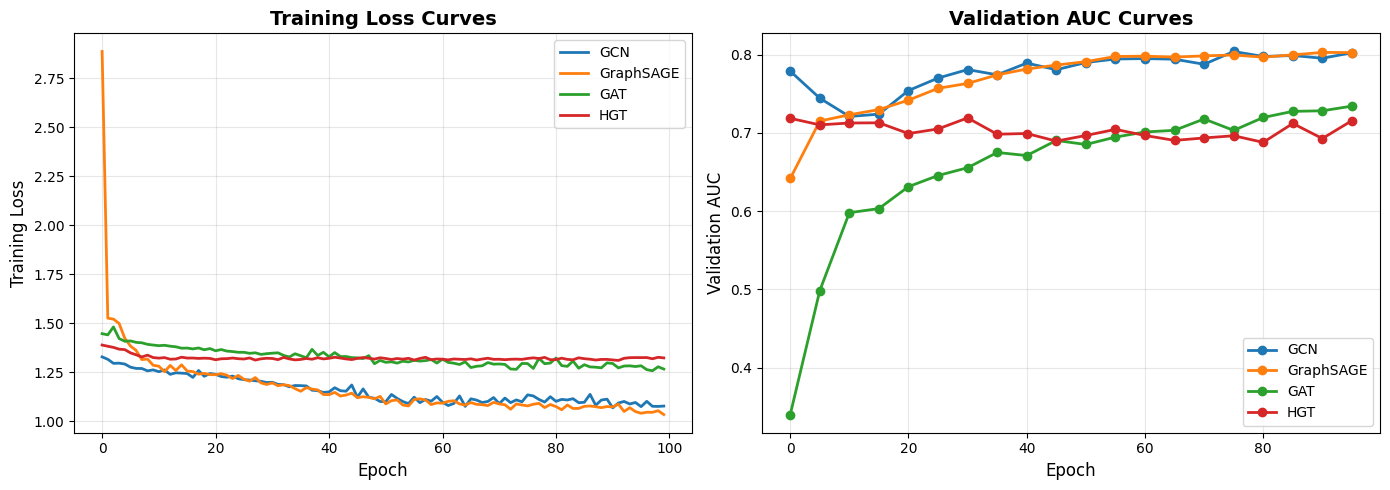

Training curves saved to training_curves.png
Full results saved to full_results.json


In [14]:
# Plot training curves
plot_training_curves(all_results)

# Save full results
with open('full_results.json', 'w') as f:
    json.dump(all_results, f, indent=2, default=str)
print("Full results saved to full_results.json")

# 4. Ablation Experiments

In [15]:
class AblationExperiments:
    """Run systematic ablation studies"""
    
    def __init__(self, dataset):
        self.dataset = dataset
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.results = []
        
    def feature_ablation(self):
        """Test impact of different feature sets"""
        print("="*80)
        print("ABLATION STUDY 1: FEATURE ABLATION")
        
        experiments = [
            ('Full Features', None),
            ('Demographics Only', 'demographics'),
            ('No Demographics', 'no_demographics'),
            ('Random Features', 'random')
        ]
        
        for exp_name, feature_type in experiments:
            print(f"\n--- {exp_name} ---")
            data = self._create_data_with_features(feature_type)
            
            model = GCNLinkPredictor(
                data.x.shape[1], 64, 2, 0.5
            ).to(self.device)
            
            results = self._train_and_evaluate(model, data, exp_name)
            results['ablation_type'] = 'feature'
            results['variation'] = exp_name
            self.results.append(results)
    
    def _create_data_with_features(self, feature_type):
        """Create data with different feature configurations"""
        data = self.dataset.create_pyg_data()
        
        if feature_type == 'demographics':
            # Only keep demographic features
            num_persons = self.dataset.num_persons
            person_features = data.x[:num_persons, 1:]  # Skip year_of_birth
            condition_features = torch.randn(self.dataset.num_conditions, person_features.shape[1])
            data.x = torch.cat([person_features, condition_features], dim=0)
            
        elif feature_type == 'no_demographics':
            # Remove demographic features, keep only occurrence stats
            num_persons = self.dataset.num_persons
            person_features = data.x[:num_persons, :1]  # Only year_of_birth
            condition_features = data.x[num_persons:, :]
            # Pad to same dimension
            max_dim = max(person_features.shape[1], condition_features.shape[1])
            person_features = F.pad(person_features, (0, max_dim - person_features.shape[1]))
            condition_features = F.pad(condition_features, (0, max_dim - condition_features.shape[1]))
            data.x = torch.cat([person_features, condition_features], dim=0)
            
        elif feature_type == 'random':
            # Replace all features with random vectors
            data.x = torch.randn_like(data.x)
        
        return data
    
    def depth_ablation(self):
        """Test impact of model depth"""
        print("="*80)
        print("ABLATION STUDY 2: MODEL DEPTH")
        
        data = self.dataset.create_pyg_data()
        
        for num_layers in [1, 2, 3, 4]:
            print(f"\n--- {num_layers}-Layer GCN ---")
            
            model = GCNLinkPredictor(
                data.x.shape[1], 64, num_layers, 0.5
            ).to(self.device)
            
            results = self._train_and_evaluate(model, data, f"{num_layers}-Layer GCN")
            results['ablation_type'] = 'depth'
            results['variation'] = num_layers
            self.results.append(results)
    
    def aggregator_ablation(self):
        """Test different GraphSAGE aggregators"""
        print("="*80)
        print("ABLATION STUDY 3: GRAPHSAGE AGGREGATORS")
        
        data = self.dataset.create_pyg_data()
        
        # LSTM requires sorted edges, so we only test mean/max
        for aggr in ['mean', 'max']: 
            print(f"\n--- GraphSAGE with {aggr} aggregator ---")
            
            model = GraphSAGELinkPredictor(
                data.x.shape[1], 64, 2, 0.5, aggr=aggr
            ).to(self.device)
            
            results = self._train_and_evaluate(model, data, f"GraphSAGE-{aggr}")
            results['ablation_type'] = 'aggregator'
            results['variation'] = aggr
            self.results.append(results)
    
    def attention_heads_ablation(self):
        """Test different numbers of attention heads in GAT"""
        print("="*80)
        print("ABLATION STUDY 4: GAT ATTENTION HEADS")
        
        data = self.dataset.create_pyg_data()
        
        for heads in [1, 2, 4, 8]:
            print(f"\n--- GAT with {heads} attention heads ---")
            
            model = GATLinkPredictor(
                data.x.shape[1], 64, 2, heads=heads, dropout=0.5
            ).to(self.device)
            
            results = self._train_and_evaluate(model, data, f"GAT-{heads}heads")
            results['ablation_type'] = 'attention_heads'
            results['variation'] = heads
            self.results.append(results)
    
    def data_size_ablation(self):
        """Test impact of training set size on overfitting/underfitting"""
        print("="*80)
        print("ABLATION STUDY 5: TRAINING DATA SIZE")
        
        data = self.dataset.create_pyg_data()
        
        # Test different fractions of training data
        data_fractions = [0.1, 0.25, 0.5, 0.75, 1.0]
        
        for fraction in data_fractions:
            print(f"\n--- Training on {int(fraction*100)}% of data ---")
            
            # Create subset of training data
            data_subset = self._create_data_subset(data, fraction)
            
            model = GCNLinkPredictor(
                data_subset.x.shape[1], 64, 2, 0.5
            ).to(self.device)
            
            results = self._train_and_evaluate_with_overfitting_metrics(
                model, data_subset, f"GCN-{int(fraction*100)}%data"
            )
            results['ablation_type'] = 'data_size'
            results['variation'] = fraction
            self.results.append(results)
    
    def _create_data_subset(self, data, fraction):
        """Create a subset of training edges"""
        data_subset = data.clone()
        
        # Check which split attributes exist and subset them
        if hasattr(data, 'train_pos_edge_index'):
            num_train = data.train_pos_edge_index.shape[1]
            num_keep = int(num_train * fraction)
            perm = torch.randperm(num_train)[:num_keep]
            data_subset.train_pos_edge_index = data.train_pos_edge_index[:, perm]
        
        # Handle edge_label_index format (from _split_edges)
        if hasattr(data, 'edge_label_index'):
            # Find training edges (assuming they have edge_label == 1)
            if hasattr(data, 'edge_label'):
                train_mask = data.edge_label == 1
                train_edges = data.edge_label_index[:, train_mask]
                
                num_train = train_edges.shape[1]
                num_keep = int(num_train * fraction)
                perm = torch.randperm(num_train)[:num_keep]
                
                # Create new edge_label_index with subset
                subset_train_edges = train_edges[:, perm]
                
                # Keep validation/test edges
                non_train_mask = ~train_mask
                non_train_edges = data.edge_label_index[:, non_train_mask]
                non_train_labels = data.edge_label[non_train_mask]
                
                # Combine
                data_subset.edge_label_index = torch.cat([
                    subset_train_edges,
                    non_train_edges
                ], dim=1)
                
                train_labels = torch.ones(num_keep, dtype=data.edge_label.dtype)
                data_subset.edge_label = torch.cat([train_labels, non_train_labels])
        
        # If using the split from RandomLinkSplit, subset train_data
        if hasattr(data, 'train_data'):
            train_data = data.train_data
            num_train = train_data.edge_label_index.shape[1] // 2  # pos + neg
            num_keep = int(num_train * fraction)
            
            # Sample positive and negative edges proportionally
            perm_pos = torch.randperm(num_train)[:num_keep]
            perm_neg = torch.randperm(num_train)[:num_keep] + num_train
            perm = torch.cat([perm_pos, perm_neg])
            
            data_subset.train_data.edge_label_index = train_data.edge_label_index[:, perm]
            data_subset.train_data.edge_label = train_data.edge_label[perm]
        
        return data_subset
    
    def _train_and_evaluate_with_overfitting_metrics(self, model, data, exp_name):
        """Training with additional overfitting metrics"""
        results = train_model(
            model, data, epochs=100, lr=0.01,  # More epochs to observe overfitting
            device=self.device, model_name=exp_name
        )
        
        # Calculate overfitting gap (train - test performance)
        if 'train_auc' in results and 'test_auc' in results:
            results['overfitting_gap'] = results['train_auc'] - results['test_auc']
        
        return results
    
    def _train_and_evaluate(self, model, data, exp_name):
        """Quick training and evaluation"""
        results = train_model(
            model, data, epochs=50, lr=0.01, 
            device=self.device, model_name=exp_name
        )
        
        return results
    
    def plot_ablation_results(self):
        """Visualize ablation study results"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Group results by ablation type
        ablation_types = ['feature', 'depth', 'aggregator', 'attention_heads']
        titles = [
            'Feature Ablation', 
            'Model Depth',
            'GraphSAGE Aggregators',
            'GAT Attention Heads'
        ]
        
        for idx, (abl_type, title) in enumerate(zip(ablation_types, titles)):
            ax = axes[idx // 2, idx % 2]
            
            # Filter results
            filtered = [r for r in self.results if r.get('ablation_type') == abl_type]
            
            if filtered:
                variations = [r['variation'] for r in filtered]
                test_aucs = [r['test_auc'] for r in filtered]
                
                ax.bar(range(len(variations)), test_aucs, color='steelblue', alpha=0.7)
                ax.set_xticks(range(len(variations)))
                ax.set_xticklabels([str(v) for v in variations], rotation=45, ha='right')
                ax.set_ylabel('Test AUC', fontsize=11)
                ax.set_title(title, fontsize=13, fontweight='bold')
                ax.grid(True, alpha=0.3, axis='y')
                ax.set_ylim([0, 1])
                
                # Add value labels on bars
                for i, v in enumerate(test_aucs):
                    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.savefig('ablation_results.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("\nAblation results plot saved to ablation_results.png")
        plt.close()
    
    def save_results(self):
        """Save all ablation results"""
        df = pd.DataFrame([{
            'Ablation Type': r.get('ablation_type', 'N/A'),
            'Variation': r.get('variation', 'N/A'),
            'Model': r['model_name'],
            'Test AUC': r['test_auc'],
            'Test AP': r['test_ap'],
            'Best Epoch': r['best_epoch']
        } for r in self.results])
        
        df.to_csv('ablation_results.csv', index=False)
        print("Ablation results saved to ablation_results.csv")
        
        with open('ablation_results.json', 'w') as f:
            json.dump(self.results, f, indent=2, default=str)
        print("Full ablation results saved to ablation_results.json")

In [16]:
# Run all ablations
ablations = AblationExperiments(dataset)
ablations.feature_ablation()

ABLATION STUDY 1: FEATURE ABLATION

--- Full Features ---

Created edge index: torch.Size([2, 60776])
	60776 edges from persons to conditions

Created homogeneous graph:
  - Total nodes: 3525
  - Person nodes: 1842 (indices 0-1841)
  - Condition nodes: 1683 (indices 1842-3524)
  - Total edges (bidirectional): 121552
  - Node features: torch.Size([3525, 12])

Edge split:
  - Train edges: 42544 (70.0%)
  - Val edges: 9116 (15.0%)
  - Test edges: 9116 (15.0%)
TRAINING Full Features
Epoch 005 | Loss: 1.3231 | Val AUC: 0.7922 | Val AP: 0.7838
Epoch 010 | Loss: 1.2907 | Val AUC: 0.7885 | Val AP: 0.7888
Epoch 015 | Loss: 1.2588 | Val AUC: 0.7611 | Val AP: 0.7734
Epoch 020 | Loss: 1.2551 | Val AUC: 0.7307 | Val AP: 0.7581
Epoch 025 | Loss: 1.2406 | Val AUC: 0.7252 | Val AP: 0.7536
Epoch 030 | Loss: 1.2203 | Val AUC: 0.7420 | Val AP: 0.7671
Epoch 035 | Loss: 1.2053 | Val AUC: 0.7677 | Val AP: 0.7840
Epoch 040 | Loss: 1.1893 | Val AUC: 0.7741 | Val AP: 0.7866
Epoch 045 | Loss: 1.1484 | Val AUC: 

In [17]:
ablations.depth_ablation()

ABLATION STUDY 2: MODEL DEPTH

Created edge index: torch.Size([2, 60776])
	60776 edges from persons to conditions

Created homogeneous graph:
  - Total nodes: 3525
  - Person nodes: 1842 (indices 0-1841)
  - Condition nodes: 1683 (indices 1842-3524)
  - Total edges (bidirectional): 121552
  - Node features: torch.Size([3525, 12])

Edge split:
  - Train edges: 42544 (70.0%)
  - Val edges: 9116 (15.0%)
  - Test edges: 9116 (15.0%)

--- 1-Layer GCN ---
TRAINING 1-Layer GCN
Epoch 005 | Loss: 1.4037 | Val AUC: 0.5907 | Val AP: 0.5754
Epoch 010 | Loss: 1.3580 | Val AUC: 0.6264 | Val AP: 0.6103
Epoch 015 | Loss: 1.3502 | Val AUC: 0.6420 | Val AP: 0.6194
Epoch 020 | Loss: 1.3444 | Val AUC: 0.6449 | Val AP: 0.6280
Epoch 025 | Loss: 1.3403 | Val AUC: 0.6476 | Val AP: 0.6313
Epoch 030 | Loss: 1.3374 | Val AUC: 0.6533 | Val AP: 0.6322
Epoch 035 | Loss: 1.3328 | Val AUC: 0.6558 | Val AP: 0.6362
Epoch 040 | Loss: 1.3340 | Val AUC: 0.6589 | Val AP: 0.6374
Epoch 045 | Loss: 1.3308 | Val AUC: 0.6515 | 

In [18]:
ablations.data_size_ablation()

ABLATION STUDY 5: TRAINING DATA SIZE

Created edge index: torch.Size([2, 60776])
	60776 edges from persons to conditions

Created homogeneous graph:
  - Total nodes: 3525
  - Person nodes: 1842 (indices 0-1841)
  - Condition nodes: 1683 (indices 1842-3524)
  - Total edges (bidirectional): 121552
  - Node features: torch.Size([3525, 12])

Edge split:
  - Train edges: 42544 (70.0%)
  - Val edges: 9116 (15.0%)
  - Test edges: 9116 (15.0%)

--- Training on 10% of data ---
TRAINING GCN-10%data
Epoch 005 | Loss: 1.3109 | Val AUC: 0.7901 | Val AP: 0.7780
Epoch 010 | Loss: 1.2843 | Val AUC: 0.7717 | Val AP: 0.7719
Epoch 015 | Loss: 1.2553 | Val AUC: 0.7480 | Val AP: 0.7653
Epoch 020 | Loss: 1.2401 | Val AUC: 0.7235 | Val AP: 0.7525
Epoch 025 | Loss: 1.2343 | Val AUC: 0.7324 | Val AP: 0.7599
Epoch 030 | Loss: 1.2101 | Val AUC: 0.7563 | Val AP: 0.7743
Epoch 035 | Loss: 1.1862 | Val AUC: 0.7811 | Val AP: 0.7887
Epoch 040 | Loss: 1.1578 | Val AUC: 0.7891 | Val AP: 0.7961
Epoch 045 | Loss: 1.1090 |

In [19]:
ablations.aggregator_ablation()

ABLATION STUDY 3: GRAPHSAGE AGGREGATORS

Created edge index: torch.Size([2, 60776])
	60776 edges from persons to conditions

Created homogeneous graph:
  - Total nodes: 3525
  - Person nodes: 1842 (indices 0-1841)
  - Condition nodes: 1683 (indices 1842-3524)
  - Total edges (bidirectional): 121552
  - Node features: torch.Size([3525, 12])

Edge split:
  - Train edges: 42544 (70.0%)
  - Val edges: 9116 (15.0%)
  - Test edges: 9116 (15.0%)

--- GraphSAGE with mean aggregator ---
TRAINING GraphSAGE-mean
Epoch 005 | Loss: 1.4259 | Val AUC: 0.6921 | Val AP: 0.6777
Epoch 010 | Loss: 1.3530 | Val AUC: 0.7098 | Val AP: 0.6897
Epoch 015 | Loss: 1.2691 | Val AUC: 0.7230 | Val AP: 0.7024
Epoch 020 | Loss: 1.2494 | Val AUC: 0.7335 | Val AP: 0.7067
Epoch 025 | Loss: 1.2432 | Val AUC: 0.7347 | Val AP: 0.7116
Epoch 030 | Loss: 1.2275 | Val AUC: 0.7387 | Val AP: 0.7171
Epoch 035 | Loss: 1.2003 | Val AUC: 0.7474 | Val AP: 0.7297
Epoch 040 | Loss: 1.1980 | Val AUC: 0.7504 | Val AP: 0.7327
Epoch 045 | L

In [20]:
ablations.attention_heads_ablation()

ABLATION STUDY 4: GAT ATTENTION HEADS

Created edge index: torch.Size([2, 60776])
	60776 edges from persons to conditions

Created homogeneous graph:
  - Total nodes: 3525
  - Person nodes: 1842 (indices 0-1841)
  - Condition nodes: 1683 (indices 1842-3524)
  - Total edges (bidirectional): 121552
  - Node features: torch.Size([3525, 12])

Edge split:
  - Train edges: 42544 (70.0%)
  - Val edges: 9116 (15.0%)
  - Test edges: 9116 (15.0%)

--- GAT with 1 attention heads ---
TRAINING GAT-1heads
Epoch 005 | Loss: 1.3964 | Val AUC: 0.3795 | Val AP: 0.4292
Epoch 010 | Loss: 1.3872 | Val AUC: 0.5054 | Val AP: 0.4965
Epoch 015 | Loss: 1.3796 | Val AUC: 0.5800 | Val AP: 0.5259
Epoch 020 | Loss: 1.3624 | Val AUC: 0.6016 | Val AP: 0.5696
Epoch 025 | Loss: 1.3445 | Val AUC: 0.6087 | Val AP: 0.5750
Epoch 030 | Loss: 1.3435 | Val AUC: 0.6008 | Val AP: 0.5721
Epoch 035 | Loss: 1.3488 | Val AUC: 0.6155 | Val AP: 0.5830
Epoch 040 | Loss: 1.3428 | Val AUC: 0.6261 | Val AP: 0.5869
Epoch 045 | Loss: 1.337

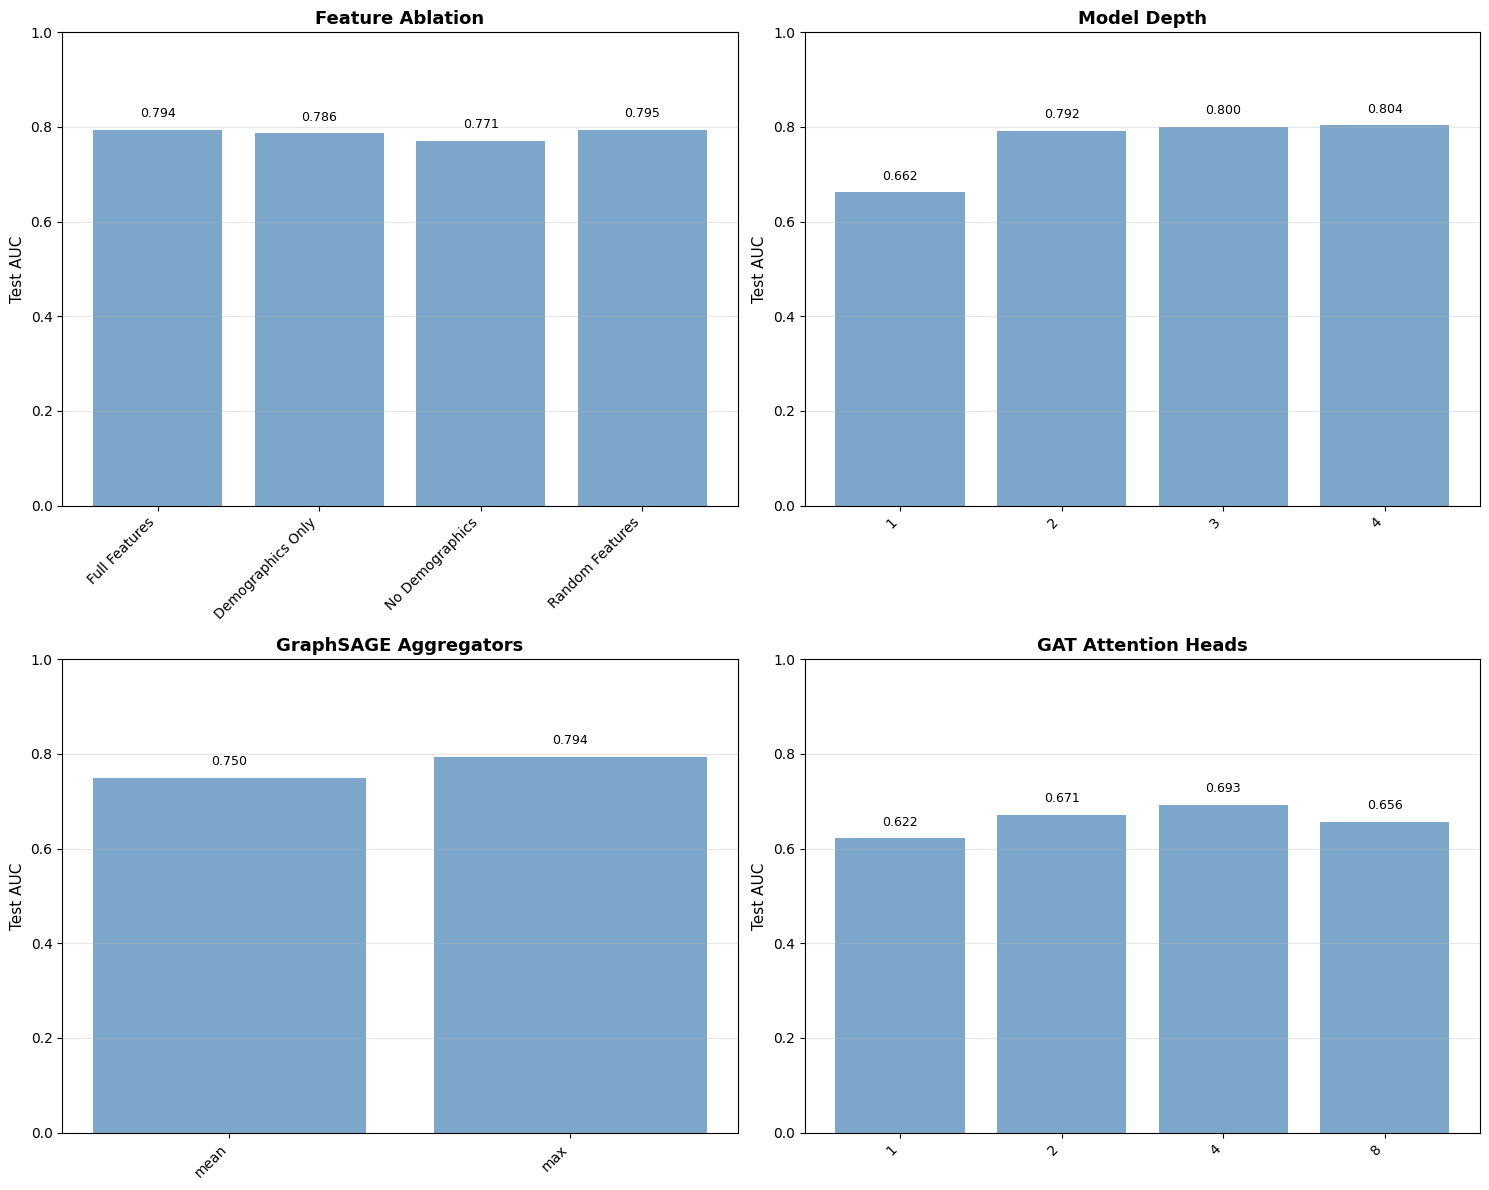


Ablation results plot saved to ablation_results.png
Ablation results saved to ablation_results.csv
Full ablation results saved to ablation_results.json


In [21]:
# Save and visualize results
ablations.plot_ablation_results()
ablations.save_results()

# 5. Visualize and Interpret Graphs

In [22]:
class ModelInterpreter:
    """Interpret and visualize GNN models"""
    
    def __init__(self, dataset, data, model_paths):
        self.dataset = dataset
        self.data = data
        self.model_paths = model_paths
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    def analyze_all_models(self):
        """Run all interpretation analyses"""
        for model_name, model_path in self.model_paths.items():
            print(f"Analyzing {model_name}")
            print(f"{'='*80}")
            
            # Load model
            model = self._load_model(model_name, model_path)
            
            # Run analyses
            self.visualize_embeddings(model, model_name)
            self.analyze_predictions(model, model_name)
        
        # Comparative analyses
        self.compare_models()
        self.clinical_case_studies()
    
    def _load_model(self, model_name, model_path):
        """Load trained model"""
        if 'GCN' in model_name:
            model = GCNLinkPredictor(self.data.x.shape[1], 64, 2, 0.5)
        elif 'GraphSAGE' in model_name:
            model = GraphSAGELinkPredictor(self.data.x.shape[1], 64, 2, 0.5)
        elif 'GAT' in model_name:
            model = GATLinkPredictor(self.data.x.shape[1], 64, 2, 4, 0.5)
        else:
            model = HGTLinkPredictor(self.data.x.shape[1], 64, 2, 4)
        
        model.load_state_dict(torch.load(model_path))
        model.to(self.device)
        model.eval()
        
        return model
    
    def visualize_embeddings(self, model, model_name):
        """Visualize node embeddings using t-SNE"""
        print(f"\n--- Generating embedding visualization for {model_name} ---")
        
        with torch.no_grad():
            # Get embeddings
            embeddings = model.encode(
                self.data.x.to(self.device),
                self.data.train_edge_index_full.to(self.device)
            ).cpu().numpy()
        
        # Separate person and condition embeddings
        num_persons = self.data.num_persons
        person_embeddings = embeddings[:num_persons]
        condition_embeddings = embeddings[num_persons:]
        
        # Sample for visualization (if too many nodes)
        max_nodes = 500
        if len(person_embeddings) > max_nodes:
            person_idx = np.random.choice(len(person_embeddings), max_nodes, replace=False)
            person_embeddings = person_embeddings[person_idx]
        if len(condition_embeddings) > max_nodes:
            condition_idx = np.random.choice(len(condition_embeddings), max_nodes, replace=False)
            condition_embeddings = condition_embeddings[condition_idx]
        
        # Combine and run t-SNE
        all_embeddings = np.vstack([person_embeddings, condition_embeddings])
        labels = ['Person'] * len(person_embeddings) + ['Condition'] * len(condition_embeddings)
        
        print("  Running t-SNE...")
        tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
        embeddings_2d = tsne.fit_transform(all_embeddings)
        
        # Plot
        fig, ax = plt.subplots(figsize=(12, 10))
        
        # Plot persons
        person_mask = np.array(labels) == 'Person'
        ax.scatter(embeddings_2d[person_mask, 0], embeddings_2d[person_mask, 1],
                  c='steelblue', alpha=0.6, s=50, label='Person Nodes', edgecolors='darkblue', linewidth=0.5)
        
        # Plot conditions
        condition_mask = np.array(labels) == 'Condition'
        ax.scatter(embeddings_2d[condition_mask, 0], embeddings_2d[condition_mask, 1],
                  c='coral', alpha=0.6, s=50, label='Condition Nodes', edgecolors='darkred', linewidth=0.5)
        
        ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
        ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
        ax.set_title(f'{model_name}: Node Embedding Visualization (t-SNE)', 
                    fontsize=14, fontweight='bold')
        ax.legend(fontsize=11, loc='best')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{model_name.lower().replace(" ", "_")}_embeddings.png', 
                   dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"Saved embedding visualization")
    
    def analyze_predictions(self, model, model_name):
        """Analyze model predictions on test set"""

        data = self.data
        device = self.device
        x = data.x.to(device)

        num_persons = data.num_persons
        num_conditions = data.num_conditions
        person_min, person_max = data.person_node_range
        cond_min, cond_max = data.condition_node_range

        # Predict positive edges
        test_pos = data.test_edge_index.to(device)

        with torch.no_grad():
            pos_logits = model(x, data.train_edge_index_full.to(device), test_pos)
            pos_pred = torch.sigmoid(pos_logits).cpu().numpy()

        # Build adjacencey set of positive edges
        full_pc_edges = torch.cat([
            data.train_edge_index,
            data.val_edge_index,
            data.test_edge_index
        ], dim=1).cpu()

        # For fast membership tests
        full_edge_set = set(
            (int(u), int(v))
            for u, v in full_pc_edges.t().tolist()
        )

        # Sample negative edges
        neg_edges = []
        needed = test_pos.size(1)

        rng = np.random.default_rng()

        while len(neg_edges) < needed:
            # sample persons and conditions
            p = rng.integers(person_min, person_max, size=needed)
            c = rng.integers(cond_min, cond_max, size=needed)

            for u, v in zip(p, c):
                if (u, v) not in full_edge_set:   # ensure it's truly negative
                    neg_edges.append((u, v))
                if len(neg_edges) == needed:
                    break

        neg_edges = torch.tensor(neg_edges, dtype=torch.long).t().to(device)

        # Predict negative edges
        with torch.no_grad():
            neg_logits = model(x, data.train_edge_index_full.to(device), neg_edges)
            neg_pred = torch.sigmoid(neg_logits).cpu().numpy()

        # Plot histogram and PR curve
        all_preds = np.concatenate([pos_pred, neg_pred])
        all_labels = np.concatenate([
            np.ones_like(pos_pred),
            np.zeros_like(neg_pred)
        ])

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Prediction distributions
        axes[0].hist(pos_pred, bins=50, alpha=0.7, label="Positive Edges", color="green", density=True)
        axes[0].hist(neg_pred, bins=50, alpha=0.7, label="Negative Edges", color="red", density=True)
        axes[0].set_xlabel("Prediction Score")
        axes[0].set_ylabel("Density")
        axes[0].set_title(f"{model_name}: Prediction Distribution")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # PR curve
        precision, recall, _ = precision_recall_curve(all_labels, all_preds)
        axes[1].plot(recall, precision)
        axes[1].fill_between(recall, precision, alpha=0.3)
        axes[1].set_xlabel("Recall")
        axes[1].set_ylabel("Precision")
        axes[1].set_title(f"{model_name}: Precision-Recall Curve")
        axes[1].set_xlim([0, 1])
        axes[1].set_ylim([0, 1])
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(
            f"{model_name.lower().replace(' ', '_')}_predictions.png",
            dpi=300,
            bbox_inches='tight'
        )
        plt.close()

        return {
            "pos_mean": float(pos_pred.mean()),
            "pos_std": float(pos_pred.std()),
            "neg_mean": float(neg_pred.mean()),
            "neg_std": float(neg_pred.std()),
            "separation": float(pos_pred.mean() - neg_pred.mean())
        }
    
    def compare_models(self):
        """Compare all models side by side"""
        print("\n--- Generating model comparison visualizations ---")
        
        # Load results
        if os.path.exists('model_comparison.csv'):
            results = pd.read_csv('model_comparison.csv')
            
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            
            # AUC comparison
            axes[0].bar(range(len(results)), results['Test AUC'], 
                       color=['steelblue', 'coral', 'green', 'purple'][:len(results)], alpha=0.7)
            axes[0].set_xticks(range(len(results)))
            axes[0].set_xticklabels(results['Model'], rotation=45, ha='right')
            axes[0].set_ylabel('Test AUC', fontsize=11)
            axes[0].set_title('Model Comparison: Test AUC', fontsize=13, fontweight='bold')
            axes[0].grid(True, alpha=0.3, axis='y')
            axes[0].set_ylim([0.8, 0.95])
            
            # Add value labels
            for i, v in enumerate(results['Test AUC']):
                axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
            
            # AP comparison
            axes[1].bar(range(len(results)), results['Test AP'], 
                       color=['steelblue', 'coral', 'green', 'purple'][:len(results)], alpha=0.7)
            axes[1].set_xticks(range(len(results)))
            axes[1].set_xticklabels(results['Model'], rotation=45, ha='right')
            axes[1].set_ylabel('Test Average Precision', fontsize=11)
            axes[1].set_title('Model Comparison: Test AP', fontsize=13, fontweight='bold')
            axes[1].grid(True, alpha=0.3, axis='y')
            axes[1].set_ylim([0.8, 0.95])
            
            # Add value labels
            for i, v in enumerate(results['Test AP']):
                axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
            
            plt.tight_layout()
            plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
            plt.close()
            
            print("Saved model comparison")
    
    def clinical_case_studies(self):
        """Generate clinical case studies"""
        print("\n--- Generating clinical case studies ---")
        
        # Load condition names with Kaggle path
        conditions = pd.read_csv('condition_vertices.csv')
        condition_map = dict(zip(conditions['condition_concept_id'], conditions['concept_name']))
        
        # Sample some test edges for case studies
        test_edges = self.data.test_edge_index.t().cpu().numpy()
        sample_idx = np.random.choice(len(test_edges), min(10, len(test_edges)), replace=False)
        
        case_studies = []
        for idx in sample_idx:
            person_idx, condition_idx = test_edges[idx]
            
            # Adjust condition index back to original
            condition_idx_original = condition_idx - self.data.num_persons
            
            # Get condition ID
            if 0 <= condition_idx_original < len(self.dataset.condition_ids):
                condition_id = self.dataset.condition_ids[condition_idx_original]
                condition_name = condition_map.get(condition_id, f"Condition {condition_id}")
                
                # Get person's existing conditions (from train edges)
                person_edges = self.data.train_edge_index[:, self.data.train_edge_index[0] == person_idx]
                existing_condition_indices = person_edges[1].cpu().numpy()
                existing_condition_indices = existing_condition_indices - self.data.num_persons
                
                existing_conditions = []
                for cond_idx in existing_condition_indices[:5]:  # Show first 5
                    if 0 <= cond_idx < len(self.dataset.condition_ids):
                        cond_id = self.dataset.condition_ids[cond_idx]
                        existing_conditions.append(condition_map.get(cond_id, f"Condition {cond_id}"))
                
                case_studies.append({
                    'Person ID': person_idx,
                    'Existing Conditions': ', '.join(existing_conditions) if existing_conditions else 'None in training',
                    'Predicted Condition': condition_name
                })
        
        # Save case studies
        if case_studies:
            df = pd.DataFrame(case_studies)
            df.to_csv('clinical_case_studies.csv', index=False)
            print("  Saved clinical case studies")
            print("\n  Sample Case Studies:")
            print(df.to_string(index=False, max_colwidth=50))
        else:
            print("  No valid case studies generated")

In [23]:
# Model paths
model_paths = {
    'GCN': 'best_gcn.pt',
    'GraphSAGE': 'best_graphsage.pt',
    'GAT': 'best_gat.pt'
}

# Filter existing models
model_paths = {k: v for k, v in model_paths.items() if os.path.exists(v)}

# Create interpreter
interpreter = ModelInterpreter(dataset, data, model_paths)

# Run analyses
interpreter.analyze_all_models()

print("\nGenerated files:")
print("  - interpretation_plots/*.png (visualizations)")
print("  - interpretation_plots/clinical_case_studies.csv")

Analyzing GCN

--- Generating embedding visualization for GCN ---
  Running t-SNE...
Saved embedding visualization
Analyzing GraphSAGE

--- Generating embedding visualization for GraphSAGE ---
  Running t-SNE...
Saved embedding visualization
Analyzing GAT

--- Generating embedding visualization for GAT ---
  Running t-SNE...
Saved embedding visualization

--- Generating model comparison visualizations ---
Saved model comparison

--- Generating clinical case studies ---
  Saved clinical case studies

  Sample Case Studies:
 Person ID                                Existing Conditions                                Predicted Condition
      1648 Delirium, Post-inflammatory pulmonary fibrosis,...                     Chronic systolic heart failure
       986 Second degree perineal laceration, Gestation pe... Maternal AND/OR fetal condition affecting labor...
      1115 Dehiscence of internal surgical wound, Conducti...                    Complication of internal device
      1541 Immunodef

1. TRAINING CURVES


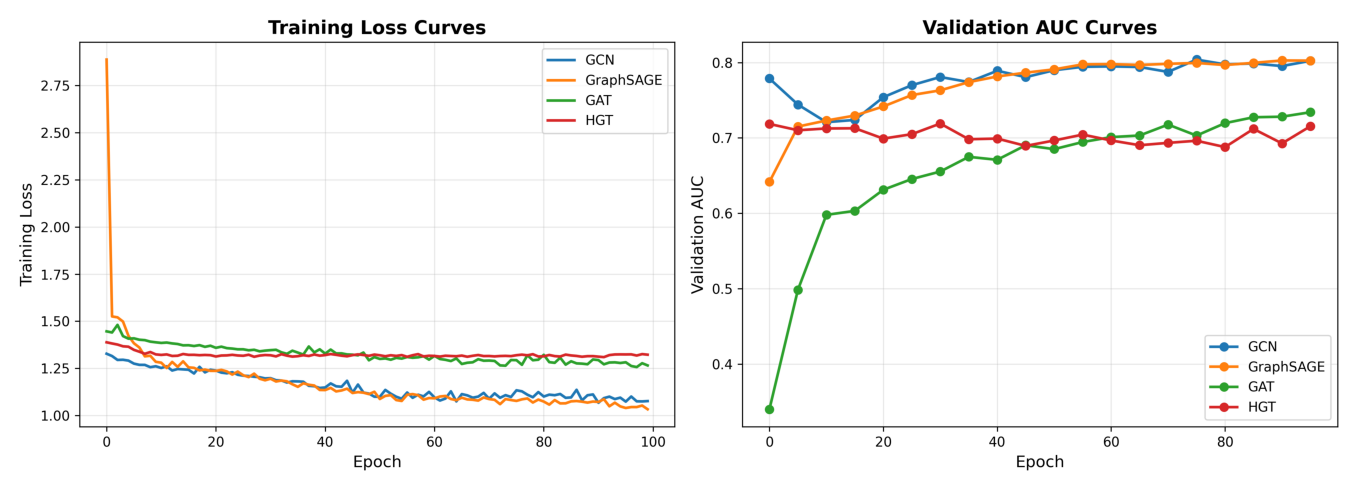


2. MODEL COMPARISON RESULTS

    Model  Test AUC  Test AP  Best Val AUC  Best Epoch
      GCN  0.801162 0.810002      0.803968          80
GraphSAGE  0.803260 0.791182      0.802794          95
      GAT  0.727921 0.698853      0.734130         100
      HGT  0.716520 0.701616      0.719073          35

3. ABLATION STUDY RESULTS


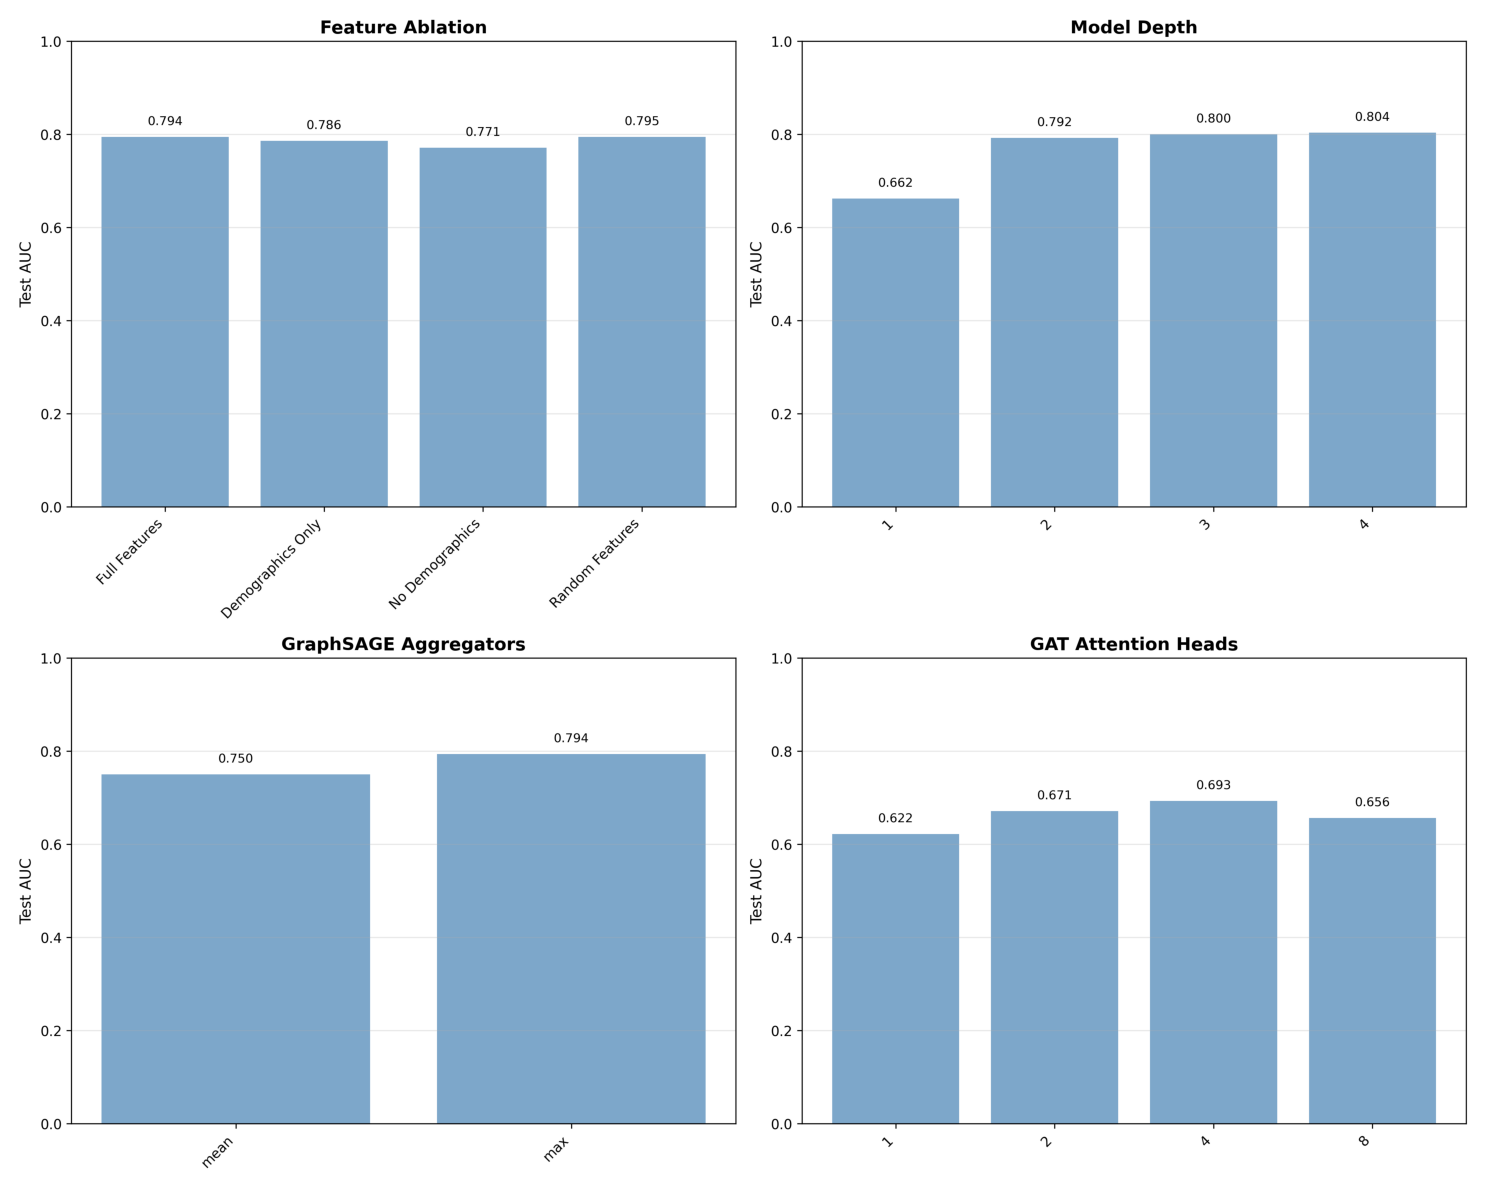


  Ablation Type         Variation             Model  Test AUC  Test AP  Best Epoch
        feature     Full Features     Full Features  0.794417 0.802417          50
        feature Demographics Only Demographics Only  0.786270 0.776207           5
        feature   No Demographics   No Demographics  0.771281 0.757622           5
        feature   Random Features   Random Features  0.794554 0.792550          50
          depth                 1       1-Layer GCN  0.661890 0.637186          40
          depth                 2       2-Layer GCN  0.792375 0.800356          50
          depth                 3       3-Layer GCN  0.800204 0.788440          10
          depth                 4       4-Layer GCN  0.803602 0.795445           5
      data_size               0.1       GCN-10%data  0.808153 0.811293          95
      data_size              0.25       GCN-25%data  0.808183 0.814134          85
      data_size               0.5       GCN-50%data  0.805854 0.810218          80
   

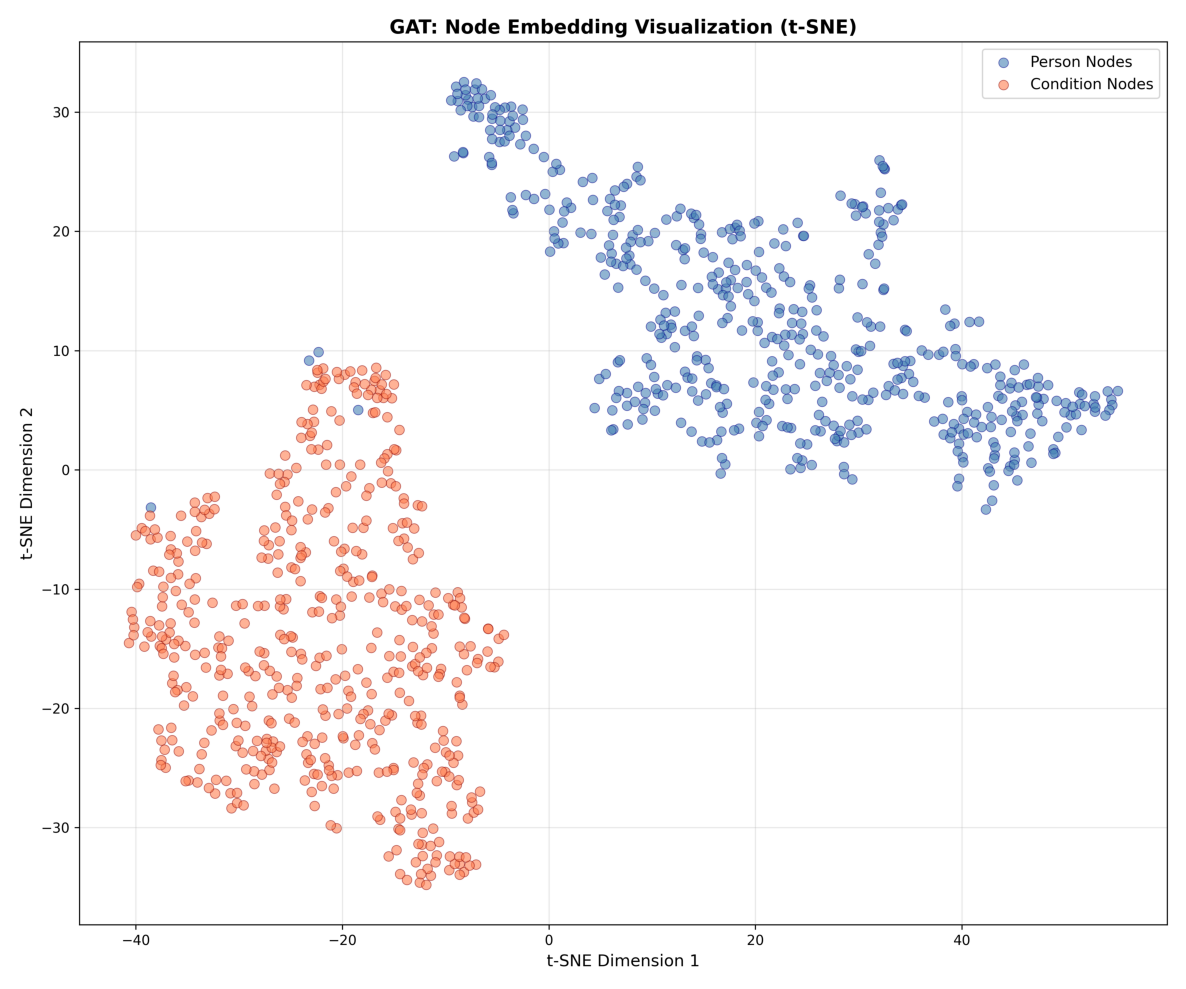


GCN Embeddings:


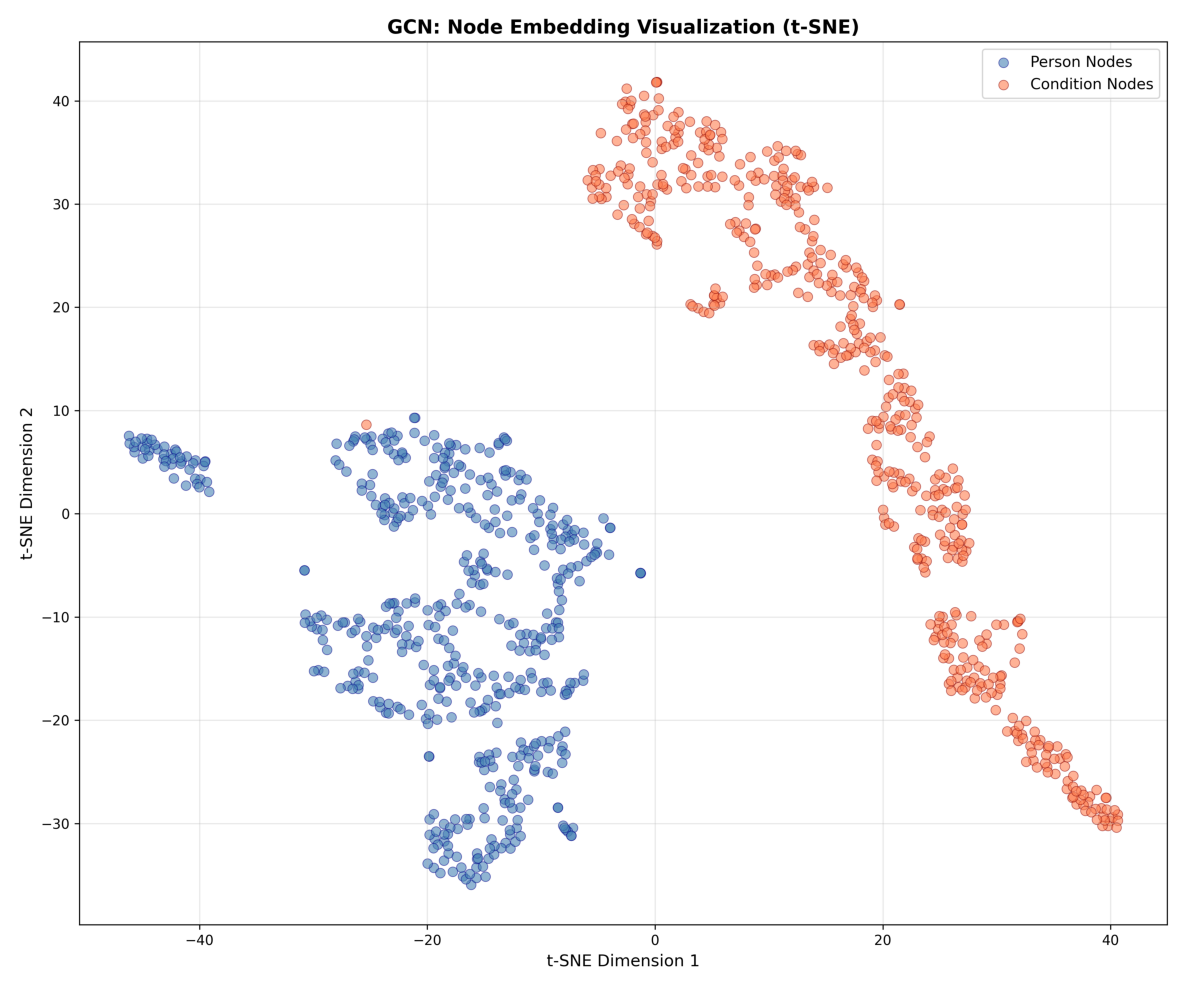


GRAPHSAGE Embeddings:


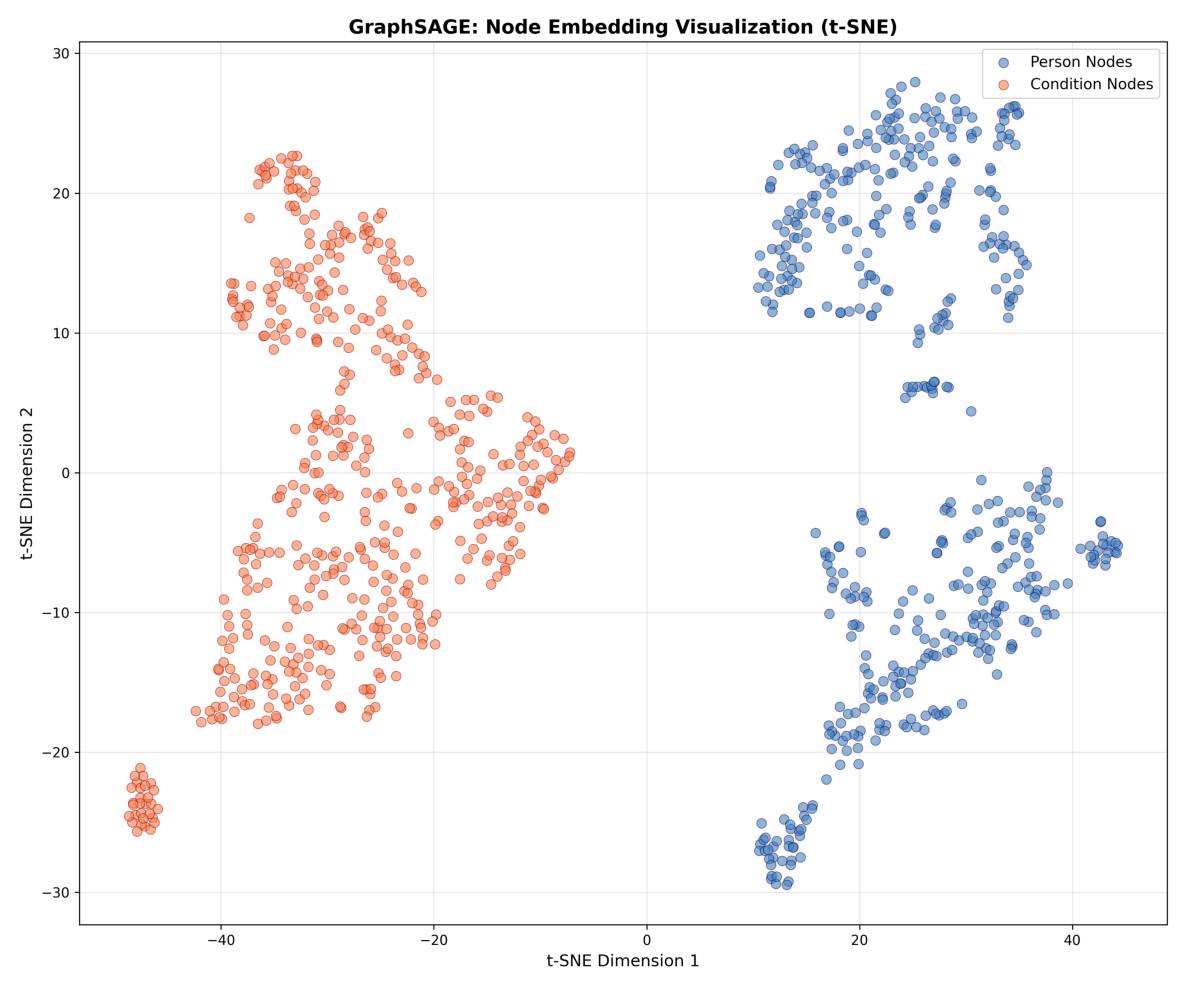


5. MODEL INTERPRETATION - PREDICTIONS

GAT Predictions:


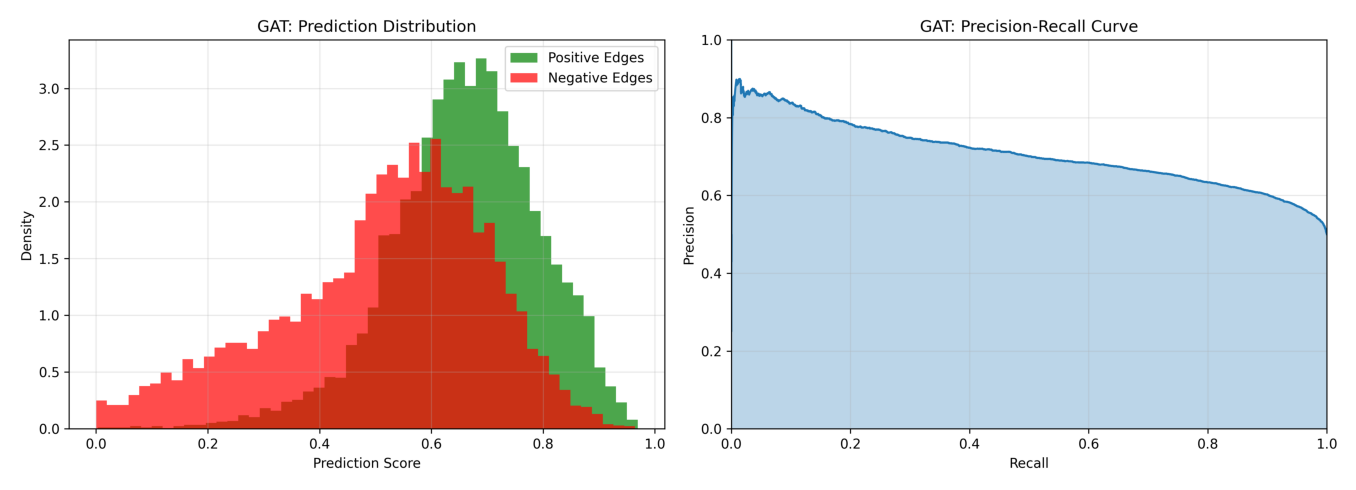


GCN Predictions:


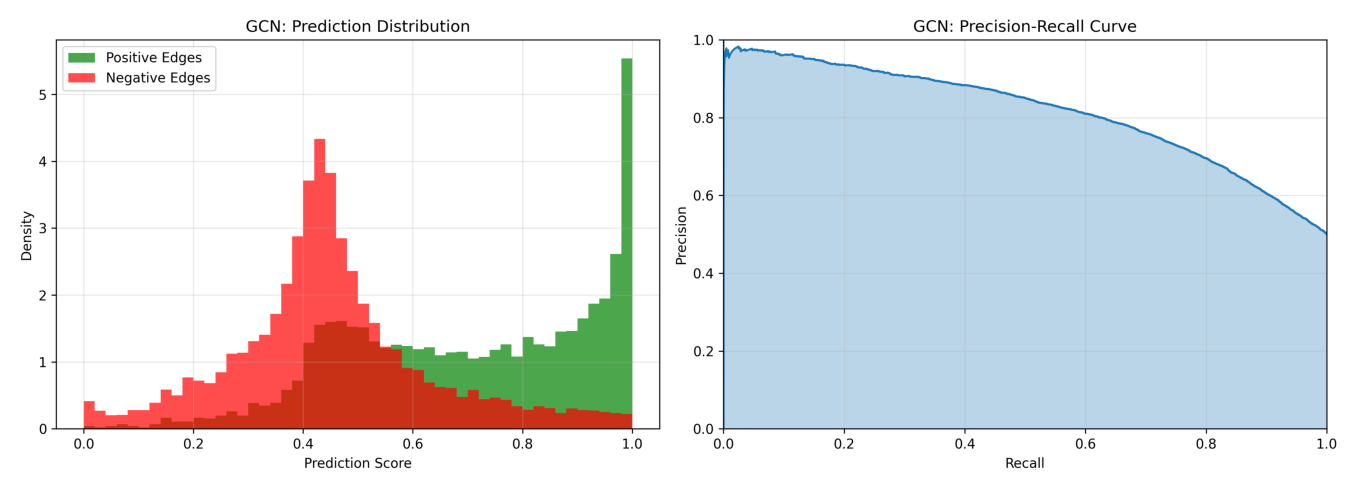


GRAPHSAGE Predictions:


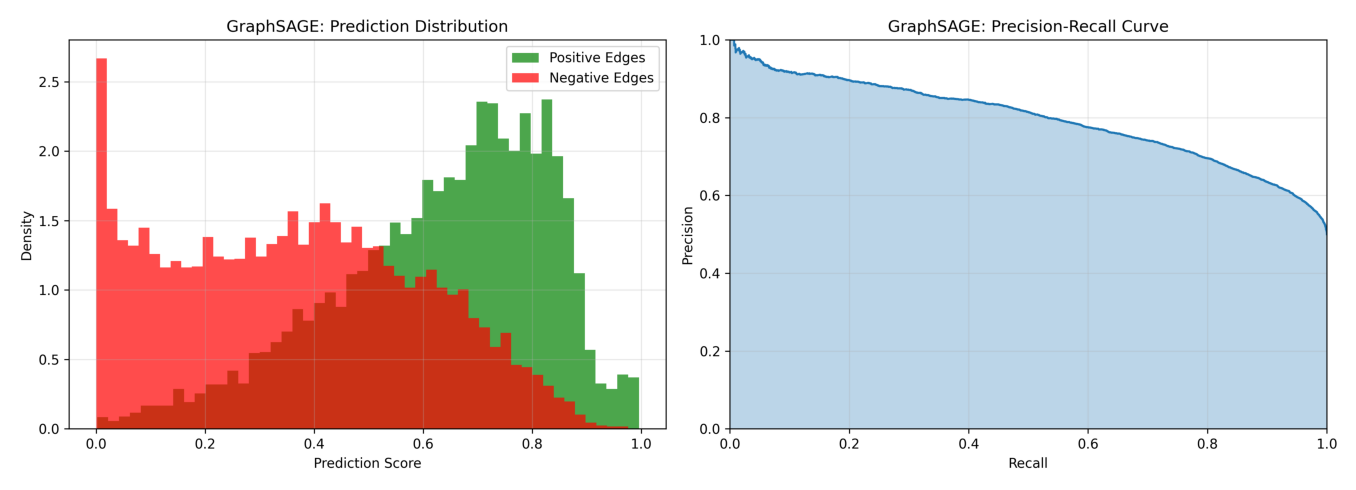


6. MODEL COMPARISON VISUALIZATION


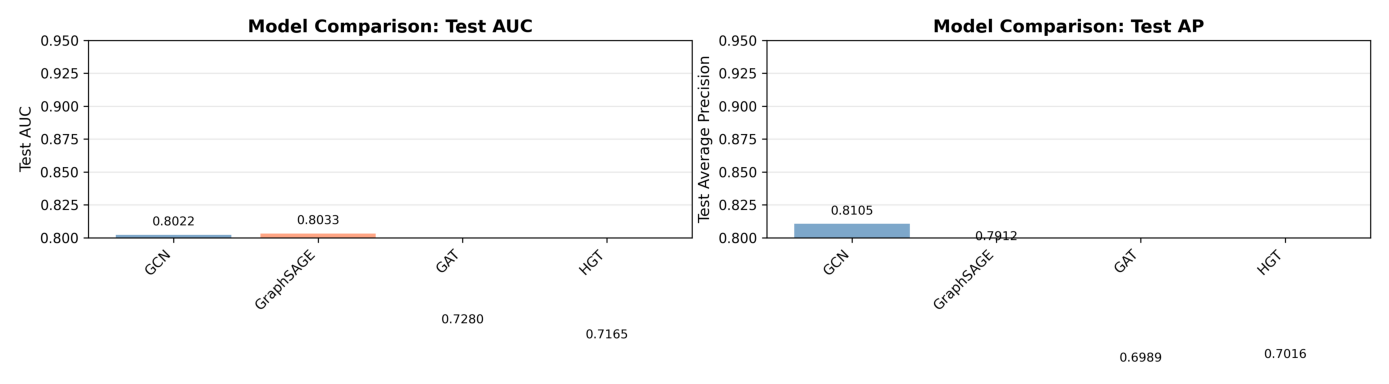

In [24]:
print("1. TRAINING CURVES")
print("=" * 80)
if os.path.exists('training_curves.png'):
    img = mpimg.imread('training_curves.png')
    plt.figure(figsize=(14, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display model comparison results
print("\n2. MODEL COMPARISON RESULTS")
print("=" * 80)
if os.path.exists('model_comparison.csv'):
    results_df = pd.read_csv('model_comparison.csv')
    print("\n" + results_df.to_string(index=False))

# Display ablation results
print("\n3. ABLATION STUDY RESULTS")
print("=" * 80)
if os.path.exists('ablation_outputs/ablation_results.png'):
    img = mpimg.imread('ablation_outputs/ablation_results.png')
    plt.figure(figsize=(15, 12))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if os.path.exists('ablation_outputs/ablation_results.csv'):
    ablation_df = pd.read_csv('ablation_outputs/ablation_results.csv')
    print("\n" + ablation_df.to_string(index=False))

# Display interpretation plots
print("\n4. MODEL INTERPRETATION - EMBEDDINGS")
print("=" * 80)

interpretation_dir = 'interpretation_plots'
if os.path.exists(interpretation_dir):
    embedding_files = [f for f in os.listdir(interpretation_dir) if 'embeddings' in f and f.endswith('.png')]
    
    for i, filename in enumerate(sorted(embedding_files), 1):
        filepath = os.path.join(interpretation_dir, filename)
        model_name = filename.replace('_embeddings.png', '').replace('_', ' ').upper()
        
        print(f"\n{model_name} Embeddings:")
        img = mpimg.imread(filepath)
        plt.figure(figsize=(12, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

print("\n5. MODEL INTERPRETATION - PREDICTIONS")
print("=" * 80)

if os.path.exists(interpretation_dir):
    prediction_files = [f for f in os.listdir(interpretation_dir) if 'predictions' in f and f.endswith('.png')]
    
    for filename in sorted(prediction_files):
        filepath = os.path.join(interpretation_dir, filename)
        model_name = filename.replace('_predictions.png', '').replace('_', ' ').upper()
        
        print(f"\n{model_name} Predictions:")
        img = mpimg.imread(filepath)
        plt.figure(figsize=(14, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

# Display model comparison visualization
print("\n6. MODEL COMPARISON VISUALIZATION")
print("=" * 80)

if os.path.exists(os.path.join(interpretation_dir, 'model_comparison.png')):
    img = mpimg.imread(os.path.join(interpretation_dir, 'model_comparison.png'))
    plt.figure(figsize=(14, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()